# Проект «Сервис прогнозирования инцидентов и управления ремонтными работами инженерных коллекторов Москвы»

**Направление: «Пожарный риск»**

Раннее предупреждение о повышенном риске пожара/задымления в коллекторе на основе динамики показаний температурных и дымовых датчиков, состояния систем безопасности и корреляции с графиками сварочных и горячих работ (АРМ-Контроль).

### Структуры данных

**Справочник каналов и датчиков:**
 - `ид_канала_данных` (PK)
 - `тип_инж_системы` (6 подсистем)
 - `тип_датчика` (19 типов)
 - `тег_инженерной_системы`
 - `название_датчика`
 - `ид_объект` (FK)

**Справочник объектов:** 
 - `ид_объект` (PK)
 - `иерархия_уровень`
 - `родитель`
 - `вид_объекта` (controlHouse / guardObject / district)
 - `диспетчерское_название_объекта`

**Журнал событий (журнал фиксирует данные с датчиков):**
 - `ид_события` (PK)
 - `ид_канала_данных` (FK)
 - `дата`
 - `время`
 - `тревожное`
 - `значение_датчика`

## 1. Среда и конфигурация сервиса

### 1.1. Импорт библиотек

In [1]:
!pip install -q lightgbm catboost

import os
import re
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    brier_score_loss,
)

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

pd.set_option('display.max_columns', 60)

### 1.2. Глобальные переменные

In [2]:
isFullAnalyzeMode = True # Выводить больше аналитической информации
SEED = 42 # начальное значение для генератора псевдослучайных чисел (для воспроизводимости результатов)

# ВХОДНЫЕ данные для модели (ОБЯЗАТЕЛЬНЫЕ!): выдали для конкурса
DATA_FOLDER = Path(os.environ.get('FIRE_DATA_FOLDER', r'C:\Users\a.rodin\1. PROJECTS_FOLDER\LST2026\data'))
SENSOR_CHANNEL_FILE = DATA_FOLDER / 'справочник_каналов_датчиков.csv'
OBJECTS_FILE = DATA_FOLDER / 'справочник_объектов_диспетчер.csv'
JOURNAL_FILES = sorted(DATA_FOLDER.glob('ext-journal-*.csv')) # файлы с данными по заданному шаблону

# ВХОДНЫЕ данные для модели (НЕ ОБЯЗАТЕЛЬНЫЕ!): внешние источники (если файла соответствующего нет, то будем пропускать)
# Формат: [ид_объект], [начало], [окончание], [тип_работ]
HOT_WORKS_FILE = DATA_FOLDER / 'арм_контроль_горячие_работы.csv'
# Формат: [дата и время], [температура], [влажность]
WEATHER_FILE = DATA_FOLDER / 'погода_часовая.csv'               
# Формат: [ид_объект], [datetime]
INCIDENTS_FILE = DATA_FOLDER / 'реестр_пожарных_инцидентов.csv'   

# ВЫХОДНЫЕ данные
OUT_FOLDER = Path(os.environ.get('FIRE_OUT_FOLDER', 'artifacts_fire_v2'))
OUT_FOLDER.mkdir(parents=True, exist_ok=True)

# Очистка данных
TEMP_FAULT_CODES   = {128.0, 136.0} # Тут будут служебные значения, чтобы удалить из анализа
TEMP_FIRE_C        = 60.0 # Порог пожара по температуре
TEMP_PERSIST_C     = 50.0 # Порог длительного перегрева
TEMP_PERSIST_WIN   = pd.Timedelta(minutes=30) # Окно времени для проверки
GAS_ALARM          = 2.0 # Порог газовой тревоги
GAS_RISK           = 1.0 # Порог газового риска
GAS_IMPLAUSIBLE    = 100.0 # Недостоверное показание газа

# Эпизоды и таргет
EP_GAP             = pd.Timedelta(hours=4) # разрыв, после которого начинается новый эпизод
EP_CONFIRM_WINDOW  = pd.Timedelta(minutes=15) # 2 разных канала в пределах окна = подтверждение
COOLDOWN           = pd.Timedelta(hours=24) # исключаем из обучения после конца эпизода
HORIZONS           = [6, 24, 72] # веменные горизонты
MAIN_H             = 24 # 24 часа

# Валидация
EMBARGO            = pd.Timedelta(days=7) # ≥ самого длинного окна признаков
N_FOLDS            = 12 # разбиение фолды
TEST_FOLD_MONTHS   = 6
VAL_DAYS           = 60

# Политика тревог
FA_BUDGET          = 0.9    # допустимо ложных тревог на единицу мониторинга в месяц

# Выбор основной модели и рабочей точки (баланс precision / recall по эпизодам)
MAIN_MODEL_CANDIDATES = ['cb', 'lgb', 'ens']  # лучшая из них выбирается автоматически на val (раздел 7.2)
THR_OBJECTIVE = 'fbeta'  # 'fbeta' — макс. F-beta(precision, recall) при FA ≤ FA_BUDGET;
F_BETA = 2.0 # 1.0 — precision и recall равноценны; 2.0 — важнее recall; 0.5 — важнее precision

FIRE_DET_TYPES = ['Датчик дыма', 'Тепловой датчик', 'Ручной извещатель']

In [3]:
print('Журналов найдено:', len(JOURNAL_FILES))
for f in JOURNAL_FILES: print('  ', f.name)
assert JOURNAL_FILES, 'Не найдено ни одного ext-journal-*.csv в DATA_FOLDER'

Журналов найдено: 6
   ext-journal-2019.csv
   ext-journal-2020.csv
   ext-journal-2021.csv
   ext-journal-2022.csv
   ext-journal-2023.csv
   ext-journal-2024.csv


## 2. Справочники

### 2.1. Подготовка данных: SENSOR_CHANNEL_FILE

In [4]:
channels = pd.read_csv(SENSOR_CHANNEL_FILE)
objects  = pd.read_csv(OBJECTS_FILE)

In [5]:
channels['тип_датчика'] = channels['тип_датчика'].astype(str).str.strip()
channels['unit'] = channels['ид_объект'].astype(np.int64)
channels = channels.set_index('ид_канала_данных')
TYPE_CATS = pd.Index(sorted(channels['тип_датчика'].unique()))
channels['type_code'] = TYPE_CATS.get_indexer(channels['тип_датчика']).astype(np.int16)

In [6]:
if isFullAnalyzeMode:
    display(channels.head())

,тип_инж_системы,тип_датчика,тег_инженерной_системы,название_датчика,ид_объект,unit,type_code
ид_канала_данных,,,,,,,
120578,Охранная подсистема,КД АВ,15-11.1.131.2.,КД АВ ПК28,20,20,7
120504,Пожарная охрана,Тепловой датчик,15-11.1.104.2.,ТД ПК86-85,20,20,18
120298,Температурная подсистема,Датчик температуры,15-11.1.4.1.,"Темп. ВШ ПК88,5",20,20,5
120577,Пожарная охрана,Тепловой датчик,15-11.1.131.1.,ТД ПК29,20,20,18
120494,Температурная подсистема,Датчик температуры,15-11.1.99.255.,Темп. ПК87,20,20,5


In [7]:
# Статические признаки единиц мониторинга
TYPE_SHORT = { # 19 типов датчиков - даем краткие названия!
    'Датчик дыма': 'smoke', 
    'Тепловой датчик': 'heat', 
    'Ручной извещатель': 'manual',
    'Газовый датчик': 'gas', 
    'Датчик температуры': 'temp', 
    'Состояние фазы': 'power',
    'Состояние насоса': 'pump', 
    'Состояние вентилятора': 'fan', 
    'Состояние охраны': 'guard',
    'ИБП': 'ibp', 
    'Состояние УИР-Р': 'uir', 
    'Датчик затопления': 'flood', 
    'КД Дверь': 'door',
    'КД Люк': 'hatch', 
    'КД АВ': 'av', 
    'Датчик движения': 'motion', 
    'Стекло': 'glass',
    'Переключатель': 'switch', 
    '9-секционный люк': 'hatch9',
}

# Группировка по unit
ch_counts = (channels.assign(t=channels['тип_датчика'].map(TYPE_SHORT).fillna('other'))
                     .groupby(['unit', 't']).size().unstack(fill_value=0).add_prefix('n_ch_'))

if isFullAnalyzeMode:
    display(ch_counts.head())

# Добавляем подсчет всего (n_ch_total) + предвестники пожара (n_ch_fire_det)
ch_counts['n_ch_total']    = ch_counts.sum(axis=1)
ch_counts['n_ch_fire_det'] = ch_counts[[c for c in ['n_ch_smoke', 'n_ch_heat', 'n_ch_manual']
                                        if c in ch_counts]].sum(axis=1)

if isFullAnalyzeMode:
    display(ch_counts.head())

# Добавляем obj, obj_kind, obj_parent, obj_level
unit_obj = channels.groupby('unit')['ид_объект'].first()
obj_info = objects.set_index('ид_объект')
static = ch_counts.copy()
static['obj']        = unit_obj
static['obj_kind']   = unit_obj.map(obj_info['вид_объекта']).astype('category').cat.codes
static['obj_parent'] = unit_obj.map(obj_info['родитель']).fillna(-1).astype(int)
static['obj_level']  = unit_obj.map(obj_info['иерархия_уровень']).fillna(-1).astype(int)
static = static.reset_index()

if isFullAnalyzeMode:
    print('\nКаналов:', len(channels), ', Объектов (единиц мониторинга):', static['unit'].nunique())
    display(static.head())

t,n_ch_av,n_ch_door,n_ch_fan,n_ch_flood,n_ch_gas,n_ch_glass,n_ch_guard,n_ch_hatch,n_ch_hatch9,n_ch_heat,n_ch_ibp,n_ch_manual,n_ch_motion,n_ch_power,n_ch_pump,n_ch_smoke,n_ch_switch,n_ch_temp,n_ch_uir
unit,,,,,,,,,,,,,,,,,,,
20,9,17,0,0,0,0,1,1,0,71,0,0,35,0,0,4,0,73,33
28,19,22,0,0,0,0,1,1,0,0,0,0,35,0,0,0,0,35,21
42,46,43,0,4,0,0,1,14,0,0,0,0,49,0,0,0,0,44,0
99,0,7,0,0,0,2,1,0,0,0,0,3,8,0,0,9,0,12,0
108,0,3,0,0,0,0,1,0,0,0,0,2,1,0,0,2,0,2,0


t,n_ch_av,n_ch_door,n_ch_fan,n_ch_flood,n_ch_gas,n_ch_glass,n_ch_guard,n_ch_hatch,n_ch_hatch9,n_ch_heat,n_ch_ibp,n_ch_manual,n_ch_motion,n_ch_power,n_ch_pump,n_ch_smoke,n_ch_switch,n_ch_temp,n_ch_uir,n_ch_total,n_ch_fire_det
unit,,,,,,,,,,,,,,,,,,,,,
20,9,17,0,0,0,0,1,1,0,71,0,0,35,0,0,4,0,73,33,244,75
28,19,22,0,0,0,0,1,1,0,0,0,0,35,0,0,0,0,35,21,134,0
42,46,43,0,4,0,0,1,14,0,0,0,0,49,0,0,0,0,44,0,201,0
99,0,7,0,0,0,2,1,0,0,0,0,3,8,0,0,9,0,12,0,42,12
108,0,3,0,0,0,0,1,0,0,0,0,2,1,0,0,2,0,2,0,11,4



Каналов: 11485 , Объектов (единиц мониторинга): 78


t,unit,n_ch_av,n_ch_door,n_ch_fan,n_ch_flood,n_ch_gas,n_ch_glass,n_ch_guard,n_ch_hatch,n_ch_hatch9,n_ch_heat,n_ch_ibp,n_ch_manual,n_ch_motion,n_ch_power,n_ch_pump,n_ch_smoke,n_ch_switch,n_ch_temp,n_ch_uir,n_ch_total,n_ch_fire_det,obj,obj_kind,obj_parent,obj_level
0,20,9,17,0,0,0,0,1,1,0,71,0,0,35,0,0,4,0,73,33,244,75,20,1,6,3
1,28,19,22,0,0,0,0,1,1,0,0,0,0,35,0,0,0,0,35,21,134,0,28,1,9,3
2,42,46,43,0,4,0,0,1,14,0,0,0,0,49,0,0,0,0,44,0,201,0,42,1,15,3
3,99,0,7,0,0,0,2,1,0,0,0,0,3,8,0,0,9,0,12,0,42,12,99,0,9,3
4,108,0,3,0,0,0,0,1,0,0,0,0,2,1,0,0,2,0,2,0,11,4,108,0,4356,3


## 3. Правила разметки событий

### 3.1.Логика правил разметки событий

| Уровень | Смысл | Где используется |
|---|---|---|
| `fire` | срабатывание пожарного извещателя / устойчивая температура ≥ 60 °C | только для построения **эпизодов** (таргет) |
| `gas` | превышение порога газа | признак |
| `risk` | фактор риска (неисправности, обесточивание, ИБП на батареях…) | признак |
| `presence` | присутствие людей/работы (двери, люки, движение, снятие с охраны, УИР-вызов) | признак, прокси горячих работ |
| `no_data` | состояние не определено | признак |
| `ok` | штатно | только общий счётчик активности |
| `drop` | мусор / неизвестное | будем удалять! |


### 3.2. Оцифровка заявленной логики

In [8]:
# Уровни (логика описана выше)
LEVELS = ['drop',     # будем удалять!
          'ok',       # штатно
          'no_data',  # состояние не определено
          'risk',     # фактор риска
          'presence', # присутствие людей/работы
          'gas',      # превышение порога газа
          'fire']     # пожар

LV = {l: i for i, l in enumerate(LEVELS)}

# Состояния пожарных извещателей
FIRE_DET_FAULT   = {'Неисправен', 'Отключено устройство', 'Неопределен', 'Выключен'}
FIRE_DET_WORKING = {'Норма', 'Дыма нет', 'Обнаружен дым', 'Не замкнут'}

# Конкретные предвестники пожара (тип, значение) → имя признака
PRECURSORS = {
    ('Датчик дыма', 'Неисправен'): 'pre_smoke_broken',
    ('Датчик дыма', 'Отключено устройство'): 'pre_smoke_off',
    ('Состояние УИР-Р', 'Рычаг сдернут'): 'pre_uir_lever',
    ('Состояние фазы', 'Обесточен'): 'pre_phase_off',
    ('Состояние фазы', 'Неисправен'): 'pre_phase_fault',
    ('Состояние насоса', 'Обесточен'): 'pre_pump_off',
    ('Состояние насоса', 'Затоплен'): 'pre_pump_flood',
    ('ИБП', 'Питание от батарей'): 'pre_ibp_battery',
    ('Состояние охраны', 'Снято с охраны'): 'pre_guard_off',
}

# Правила
RULES = {
    'Датчик дыма': {
        'Обнаружен дым': 'fire', 'Не замкнут': 'fire',
        'Норма': 'ok', 'Дыма нет': 'ok', 'Выключен': 'risk',
        'Неисправен': 'risk', 'Отключено устройство': 'risk', 'Неопределен': 'no_data',
    },
    'Тепловой датчик': {
        'Не замкнут': 'fire', 'Норма': 'ok',
        'Неисправен': 'risk', 'Отключено устройство': 'risk', 'Неопределен': 'no_data',
        'Выключен': 'risk',
    },
    'Ручной извещатель': {
        'Не замкнут': 'fire', 'Норма': 'ok',
        'Неисправен': 'risk', 'Отключено устройство': 'risk', 'Неопределен': 'no_data',
        'Рычаг сдернут': 'fire', 'Рычаг норма': 'ok', 'Выключен': 'risk',
    },
    'Газовый датчик': {
        'Обнаружен газ': 'gas', 'Срабатывание': 'gas', 
        'Норма': 'ok', 'Неопределен': 'no_data',
        'Неисправен': 'risk', 'Отключено устройство': 'risk', 'Выключен': 'risk',
    },
    'Датчик температуры': {
        'Норма': 'ok', 'Неисправен': 'risk', 'Неопределен': 'no_data',
        'В норме от +3 до +40': 'ok', 'Температура выше 40ºC': 'risk',
        'Отключено устройство': 'risk', 'Выключен': 'risk',
        'Температура ниже 3ºC': 'ok', 'Движения нет': 'ok',
    },
    'Стекло': {'Не замкнут': 'risk', 'Норма': 'ok', 'Неопределен': 'no_data', 
               'Отключено устройство': 'risk', 'Выключен': 'risk',
              },
    'КД Дверь': {
        'Не замкнут': 'presence', 'Движения нет': 'ok', 'Обнаружено движение': 'presence',
        'Норма': 'ok', 'Неопределен': 'no_data', 'Неисправен': 'risk', 'Отключено устройство': 'risk', 'Выключен': 'risk',
    },
    'КД Люк': {
        'Не замкнут': 'presence',
        'Норма': 'ok', 'Неисправен': 'risk', 'Отключено устройство': 'risk', 'Неопределен': 'no_data',
         'Выключен': 'risk',
    },
    'КД АВ': {
        'Не замкнут': 'presence',
        'Норма': 'ok', 'Неопределен': 'no_data', 'Неисправен': 'risk', 'Отключено устройство': 'risk',
        'Выключен': 'risk',
    },
    'Датчик движения': {
        'Обнаружено движение': 'presence', 'Не замкнут': 'presence', 'Движения нет': 'ok', 'Норма': 'ok',
        'Неисправен': 'ok', 'Отключено устройство': 'ok', 'Неопределен': 'no_data', 'Выключен': 'ok',
    },
    'Датчик затопления': {'Норма': 'ok', 'Не замкнут': 'risk', 'Неисправен': 'risk',
                          'Неопределен': 'no_data', 'Отключено устройство': 'risk'},
    'Состояние фазы': {
        'Обесточен': 'risk', 'Неисправен': 'risk', 'Выключен': 'risk', 'Включен': 'ok',
        'Есть питание': 'ok', 'Норма': 'ok', 'Отключено устройство': 'ok', 'Неопределен': 'no_data',
    },
    'ИБП': {
        'Питание от батарей': 'risk', 'Батарея разряжена': 'risk', 'Батарея неисправна': 'risk',
        'Неисправен': 'risk',
        'Питание от сети': 'ok', 'Норма': 'ok', 'Отключено устройство': 'ok', 'Неопределен': 'no_data',
        'Выключен': 'ok',
    },
    'Состояние насоса': {
        'Затоплен': 'risk', 'Неисправен': 'risk', 'Обесточен': 'risk',
        'Включен': 'ok', 'Выключен': 'ok', 'Норма': 'ok', 'Отключено устройство': 'ok',
        'Неопределен': 'no_data', 'Работают все насосы в АНС': 'ok',
    },
    'Состояние вентилятора': {
        'Неисправен': 'risk', 'Обесточен': 'risk',
        'Включен': 'ok', 'Выключен': 'ok', 'Норма': 'ok', 'Отключено устройство': 'ok', 'Неопределен': 'no_data',
    },
    'Состояние УИР-Р': {
        'Рычаг сдернут': 'risk', 'Не замкнут': 'risk', 'Неисправен': 'risk',
        'Вызов': 'presence', 'Разговор': 'presence',
        'Норма': 'ok', 'Рычаг норма': 'ok', 'Отключено устройство': 'ok', 'Неопределен': 'no_data', 'Выключен': 'ok',
    },
    'Состояние охраны': {
        'Норма': 'ok', 'На охране': 'ok', 'Устройства на объекте исправны': 'ok',
        'Снято с охраны': 'presence',
        'Много неисправных устройств': 'risk', 'Неопределен': 'no_data', 'Выключен': 'risk',
    },
    'Переключатель': {}, '9-секционный люк': {},
}
# Игнорируем события этих типов
IGNORE_TYPES = {'Переключатель', '9-секционный люк'}
# Нормируем значения
NORM_VALUES = {'Не определено': 'Неопределен', 'не определено': 'Неопределен', 'неопределен': 'Неопределен',
               'Неопределён': 'Неопределен', 'норма': 'Норма', 'неисправен': 'Неисправен'}
# Типы не должны содержать цифровых значений!
TYPES_NO_DIGITS = {'КД АВ', 'Тепловой датчик', 'Датчик движения', 'КД Дверь', 'Состояние УИР-Р', 'Датчик дыма',
                   'КД Люк', 'Датчик затопления', 'Ручной извещатель', 'Стекло', 'Состояние фазы',
                   'Состояние вентилятора', 'Переключатель', 'Состояние насоса', 'ИБП', '9-секционный люк'}

# регулярное выражение: вся строка похожа на дату, возможно с временем
DATE_RE = re.compile(r'^\s*\d{1,4}[./\-]\d{1,2}[./\-]\d{1,4}(\s+\d{1,2}:\d{2}(:\d{2})?)?\s*$')
# регулярное выражение: вся строка похожа на число — целое или дробное
NUM_RE  = re.compile(r'^\s*-?\d+(?:[.,]\d+)?\s*$')

# Функция classify_pair(tip, val) классифицирует пару «тип датчика — значение» и возвращает кортеж (статус, числовое_значение)
# Уровень и числовое значение для уникальной пары (тип датчика, значение).
def classify_pair(tip, val):
    if tip is None or val is None or (isinstance(val, float) and np.isnan(val)):
        return 'drop', np.nan
    v = str(val).strip()
    v = NORM_VALUES.get(v, v)
    num = float(v.replace(',', '.')) if NUM_RE.match(v) else np.nan

    if tip == 'Датчик температуры' and not np.isnan(num):
        if num in TEMP_FAULT_CODES or num > 150 or num <= -60: return 'drop', np.nan
        if num >= TEMP_FIRE_C: return 'fire', num 
        if num >= 40:          return 'risk', num
        return 'ok', num
    if tip == 'Газовый датчик' and not np.isnan(num):
        if num < 0 or num >= GAS_IMPLAUSIBLE: return 'drop', np.nan
        if num >= GAS_ALARM: return 'gas', num
        if num >= GAS_RISK:  return 'risk', num
        return 'ok', num
    if tip == 'Состояние охраны' and DATE_RE.match(v):
        return ('drop' if v.startswith('01.01.1970') else 'ok'), np.nan
    if tip in TYPES_NO_DIGITS and re.search(r'\d', v):
        return 'drop', np.nan
    if tip in IGNORE_TYPES:
        return 'drop', np.nan
    return RULES.get(tip, {}).get(v, 'unknown'), np.nan

### 3.3. Потоковая обработка журналов

1. Объем данных достаточно большой, поэтому было принято решение обработать его "потоково".

2. Каждый годовой файл читается, очищается и сворачивается в почасовые строки (**существенная экономия памяти!**).

3. В память попадают только агрегированные списки.

Это выполняет функция `process_journal`. Она выполняет следующие действия:

- даты/время разбираются по уникальным значениям категорий;
- уровень события вычисляется один раз на уникальную пару (тип, значение);
- общие счётчики не включают события пожарных извещателей уровней `fire`/`ok`;
- температура: признаки по каждому датчику;
- «слепота» извещателей: сколько извещателей сейчас неисправны;

In [9]:
# Применяет func к категориям, склеивая совпавшие после преобразования.
def _recode_categorical(cat: pd.Series, func) -> pd.Categorical:
    cats = pd.Series(cat.cat.categories.astype(str)).map(func)
    new_codes, uniques = pd.factorize(cats)
    codes = cat.cat.codes.to_numpy()
    mapped = np.where(codes >= 0, new_codes[np.clip(codes, 0, None)], -1)
    return pd.Categorical.from_codes(mapped, categories=pd.Index(uniques))
    
# Разбор даты и времени в коды [2024-01-01 08:00, 2024-01-01 09:00, 2024-01-02 08:00]
# (!) Существенная экономия места и увеличения скорости
def _parse_datetime(date_cat: pd.Series, time_cat: pd.Series) -> np.ndarray:
    d_cats = pd.Series(date_cat.cat.categories.astype(str))
    d_val = pd.to_datetime(d_cats, format='%Y-%m-%d', errors='coerce')
    if d_val.isna().mean() > 0.5:
        d_val = pd.to_datetime(d_cats, format='mixed', dayfirst=True, errors='coerce')
    t_val = pd.to_timedelta(pd.Series(time_cat.cat.categories.astype(str)).str.strip(), errors='coerce')
    d_arr = np.append(d_val.to_numpy(dtype='datetime64[ns]'), np.datetime64('NaT'))
    t_arr = np.append(t_val.to_numpy(dtype='timedelta64[ns]'), np.timedelta64('NaT'))
    return d_arr[date_cat.cat.codes.to_numpy()] + t_arr[time_cat.cat.codes.to_numpy()]

UNKNOWN_PAIRS = []

# Превращает «сырые» записи в часовую агрегированную статистику плюс отдельный набор fire-событий
# - hourly — DataFrame со статистикой по часам и объектам (unit, час)
# - fire_ev — события уровня «пожар»;
# - carry_state — обновлённое состояние пожарных извещателей
# - level_stats — сколько событий каждого уровня
def process_journal(path, carry_state):
    t0 = time.time()

    # читаем файл с данными по датчикам: ид_канала_данных, дата, время, тревожное, значение_датчика
    raw = pd.read_csv(path, usecols=['ид_канала_данных', 'дата', 'время', 'тревожное', 'значение_датчика'],
                      dtype={'ид_канала_данных': 'category', 'дата': 'category', 'время': 'category', 'тревожное': 'category', 
                             'значение_датчика': 'category'}, on_bad_lines='warn')
    
    n_raw = len(raw)
    ch_cats = pd.Series(raw['ид_канала_данных'].cat.categories.astype(str)).str.strip()    
    ch_num_cats = pd.to_numeric(ch_cats.str.replace(r'\.0+$', '', regex=True), errors='coerce').to_numpy()  
    codes = raw['ид_канала_данных'].cat.codes.to_numpy()
    ch_num = np.where(codes >= 0, ch_num_cats[np.clip(codes, 0, None)], np.nan)

    bad = np.isnan(ch_num)
    if bad.any():
        examples = raw.loc[bad, 'ид_канала_данных'].astype(str).value_counts(dropna=False).head(5)
        print(f'{Path(path).name}: {bad.sum():,} строк с нечисловым ид_канала_данных удалены. '
              f'Примеры: {examples.to_dict()}')
    raw = raw.loc[~bad].copy()
    raw['ид_канала_данных'] = ch_num[~bad].astype(np.int64)    
    
    # удаление дубликатов по указанным комбинациям колонок (всем четырем)
    raw = raw.drop_duplicates(['ид_канала_данных', 'дата', 'время', 'значение_датчика'])

    # приведение «тревожное»
    # True — если значение в 'тревожное' равно 't', 'true', '1' или 'да'
    alarm_cats = pd.Series(raw['тревожное'].cat.categories.astype(str)).str.strip().str.lower()
    alarm_map = alarm_cats.isin(['t', 'true', '1', 'да']).to_numpy()
    codes = raw['тревожное'].cat.codes.to_numpy()
    alarm = np.where(codes >= 0, alarm_map[np.clip(codes, 0, None)], False)

    # привязка к справочнику
    pos = channels.index.get_indexer(raw['ид_канала_данных'].to_numpy())
    ok_ch = pos >= 0
    ev = pd.DataFrame({
        'channel': raw['ид_канала_данных'].to_numpy()[ok_ch].astype(np.int64),
        'dt': _parse_datetime(raw['дата'], raw['время'])[ok_ch],
        'alarm': alarm[ok_ch],
        'type_code': channels['type_code'].to_numpy()[pos[ok_ch]],
        'unit': channels['unit'].to_numpy()[pos[ok_ch]],
    })
    val = _recode_categorical(raw['значение_датчика'], lambda s: NORM_VALUES.get(s.strip(), s.strip()))
    ev['val'] = pd.Categorical.from_codes(np.asarray(val.codes)[ok_ch], categories=val.categories)
    del raw

    # уровень — один раз на уникальную пару (тип, значение)
    nv = len(ev['val'].cat.categories) + 1
    key = ev['type_code'].to_numpy(np.int64) * nv + (ev['val'].cat.codes.to_numpy(np.int64) + 1)
    ukeys, inv = np.unique(key, return_inverse=True)
    lvl_u, num_u = np.empty(len(ukeys), dtype=np.int8), np.empty(len(ukeys))
    val_cats = ev['val'].cat.categories
    for i, k in enumerate(ukeys):
        tip = TYPE_CATS[k // nv]; vc = k % nv - 1
        lvl, num = classify_pair(tip, val_cats[vc] if vc >= 0 else None)
        if lvl == 'unknown':
            UNKNOWN_PAIRS.append((tip, val_cats[vc] if vc >= 0 else None, int((inv == i).sum())))
            lvl = 'drop'
        lvl_u[i], num_u[i] = LV[lvl], num
    ev['lvl'] = lvl_u[inv]
    ev['num'] = num_u[inv]
    ev['type'] = pd.Categorical.from_codes(ev['type_code'], categories=TYPE_CATS)
    ev = ev[(ev['lvl'] != LV['drop']) & ev['dt'].notna()].copy()
    ev['час'] = ev['dt'].dt.floor('h')

    # устойчивость высокой температуры
    tm = (ev['type'] == 'Датчик температуры') & ev['num'].notna()
    t = ev.loc[tm, ['channel', 'dt', 'num', 'lvl']].sort_values(['channel', 'dt'])
    g = t.groupby('channel', sort=False)
    prev_ok = (g['num'].shift(1) >= TEMP_PERSIST_C) & ((t['dt'] - g['dt'].shift(1)) <= TEMP_PERSIST_WIN)
    next_ok = (g['num'].shift(-1) >= TEMP_PERSIST_C) & ((g['dt'].shift(-1) - t['dt']) <= TEMP_PERSIST_WIN)
    spike = (t['lvl'] == LV['fire']) & ~(prev_ok | next_ok)
    ev.loc[spike[spike].index, 'lvl'] = LV['risk']

    is_fd = ev['type'].isin(FIRE_DET_TYPES).to_numpy()
    lvl = ev['lvl'].to_numpy()

    # fire-события (для эпизодов)
    fire_ev = ev.loc[lvl == LV['fire'], ['unit', 'channel', 'type', 'dt', 'num']].copy()
    fire_ev['type'] = fire_ev['type'].astype(str)

    # общая активность без fire/ok пожарных извещателей
    activity = ~(is_fd & np.isin(lvl, [LV['fire'], LV['ok']]))
    base = ev.loc[activity].groupby(['unit', 'час']).agg(
        n_events=('lvl', 'size'), n_alarm_flag=('alarm', 'sum'))

    # счётчики по уровням / типам / предвестникам
    sig = ev.loc[np.isin(lvl, [LV['risk'], LV['no_data'], LV['presence'], LV['gas']])]
    short = sig['type'].astype(str).map(TYPE_SHORT).fillna('other')
    lvl_name = pd.Series(np.array(LEVELS)[sig['lvl'].to_numpy()], index=sig.index)
    keys = [
        'n_' + lvl_name,
        ('risk_' + short).where(lvl_name == 'risk'),
        ('pres_' + short).where(lvl_name == 'presence'),
        pd.Series([PRECURSORS.get((a, b)) for a, b in zip(sig['type'].astype(str), sig['val'].astype(str))],
                  index=sig.index, dtype=object),
    ]
    long = pd.concat([pd.DataFrame({'unit': sig['unit'], 'час': sig['час'], 'k': k}) for k in keys])
    long = long.dropna(subset=['k'])
    cnt = long.groupby(['unit', 'час', 'k']).size().unstack(fill_value=0)
    uniq = (sig[lvl_name.isin(['risk', 'no_data'])]
            .assign(l=lvl_name).groupby(['unit', 'час', 'l'])['channel'].nunique()
            .unstack(fill_value=0).add_prefix('uniq_ch_'))
    gas = ev.loc[ev['type'] == 'Газовый датчик'].groupby(['unit', 'час'])['num'].max().rename('gas_max')

    hourly = base.join([cnt, uniq, gas], how='outer')

    # температура по каждому датчику
    t = ev.loc[tm & (ev['lvl'] != LV['drop']), ['unit', 'channel', 'dt', 'час', 'num']].sort_values(['channel', 'dt'])
    t = t.set_index('dt')
    gch = t.groupby('channel', sort=False)['num']
    t['base_7d'] = gch.transform(lambda s: s.shift(1).rolling('7D', min_periods=5).median())
    dt_h = t.index.to_series().groupby(t['channel'].to_numpy()).diff().dt.total_seconds().to_numpy() / 3600
    dnum = gch.diff().to_numpy()
    t['slope'] = np.where(dt_h >= 1/12, dnum / np.maximum(dt_h, 1/12), np.nan)    # °C/ч, шаг ≥ 5 мин
    t['dev'] = t['num'] - t['base_7d']
    t = t.reset_index()
    ch_hour = t.groupby(['unit', 'час', 'channel']).agg(v=('num', 'max'), dev=('dev', 'max'),
                                                         slope=('slope', 'max')).reset_index()
    ch_hour['spread'] = ch_hour['v'] - ch_hour.groupby(['unit', 'час'])['v'].transform('median')
    ch_hour['dev5'] = (ch_hour['dev'] > 5).astype(np.int16)
    temp_h = ch_hour.groupby(['unit', 'час']).agg(
        temp_max=('v', 'max'), temp_min=('v', 'min'), temp_dev_max=('dev', 'max'),
        temp_slope_max=('slope', 'max'), temp_spread_max=('spread', 'max'),
        n_temp_dev5=('dev5', 'sum'))
    hourly = hourly.join(temp_h, how='outer')

    # «слепота» пожарных извещателей (переходы состояний) ---
    fd = ev.loc[is_fd, ['unit', 'channel', 'dt', 'час', 'val']]
    vstr = fd['val'].astype(str)
    fd = fd.assign(state=np.where(vstr.isin(FIRE_DET_FAULT), 1, np.where(vstr.isin(FIRE_DET_WORKING), 0, -1)))
    fd = fd[fd['state'] >= 0].sort_values(['channel', 'dt'])
    prev = fd.groupby('channel', sort=False)['state'].shift(1)
    prev = prev.fillna(fd['channel'].map(carry_state)).fillna(0)
    fd['delta'] = fd['state'] - prev
    new_carry = fd.groupby('channel')['state'].last()
    blind = fd[fd['delta'] != 0].groupby(['unit', 'час'])['delta'].sum().rename('blind_delta')
    hourly = hourly.join(blind, how='outer').reset_index()

    carry_state = {**carry_state, **new_carry.to_dict()}
    print(f'{Path(path).name}: строк {n_raw:,} → событий {len(ev):,}, fire {len(fire_ev):,}, '
          f'часов {len(hourly):,} | {time.time() - t0:.0f} c')
    level_stats = pd.Series(np.array(LEVELS)[ev['lvl'].to_numpy()]).value_counts()
    return hourly, fire_ev, carry_state, level_stats

In [10]:
hourly_parts, fire_parts, level_stats = [], [], []
carry = {}

# Начинаем обработку ЖУРНАЛОВ с данными
for path in JOURNAL_FILES:
    print('Журнал событий на обработку:', {path})
    h, f, carry, ls = process_journal(path, carry)
    hourly_parts.append(h)
    fire_parts.append(f)
    level_stats.append(ls)
    print('Обработка журнала завершена:', {path})        
    print('-'*123)            

Журнал событий на обработку: {WindowsPath('C:/Users/a.rodin/1. PROJECTS_FOLDER/LST2026/data/ext-journal-2019.csv')}
ext-journal-2019.csv: строк 20,993,328 → событий 18,164,396, fire 5,415, часов 146,517 | 101 c
Обработка журнала завершена: {WindowsPath('C:/Users/a.rodin/1. PROJECTS_FOLDER/LST2026/data/ext-journal-2019.csv')}
---------------------------------------------------------------------------------------------------------------------------
Журнал событий на обработку: {WindowsPath('C:/Users/a.rodin/1. PROJECTS_FOLDER/LST2026/data/ext-journal-2020.csv')}
ext-journal-2020.csv: строк 28,172,398 → событий 23,437,970, fire 12,370, часов 155,308 | 132 c
Обработка журнала завершена: {WindowsPath('C:/Users/a.rodin/1. PROJECTS_FOLDER/LST2026/data/ext-journal-2020.csv')}
---------------------------------------------------------------------------------------------------------------------------
Журнал событий на обработку: {WindowsPath('C:/Users/a.rodin/1. PROJECTS_FOLDER/LST2026/data/ext-j

In [11]:
# Все часовые DataFrame склеиваются в один, формируем сквозной индекс
hourly = pd.concat(hourly_parts, ignore_index=True)
agg_cols = [c for c in hourly.columns if c not in ('unit', 'час')]
max_cols = {'gas_max', 'temp_max', 'temp_dev_max', 'temp_slope_max', 'temp_spread_max'}
hourly = hourly.groupby(['unit', 'час']).agg(
    {c: ('max' if c in max_cols else 'min' if c == 'temp_min' else 'sum') for c in agg_cols}).reset_index()
fire_events = pd.concat(fire_parts, ignore_index=True)
del hourly_parts, fire_parts

print('\nПочасовых записей:', f'{len(hourly):,}', '| fire-событий:', f'{len(fire_events):,}')
if isFullAnalyzeMode:
    print('\nУровни событий (все годы):')
    ls = pd.concat(level_stats, axis=1).sum(axis=1).sort_values(ascending=False)
    print((ls / ls.sum()).map('{:.3%}'.format).to_string())
    if UNKNOWN_PAIRS:
        print('\nНеизвестные пары (тип, значение):')
        up = pd.DataFrame(UNKNOWN_PAIRS, columns=['тип', 'значение', 'n']).groupby(['тип', 'значение'])['n'].sum()
        print(up.sort_values(ascending=False).head(20).to_string())


Почасовых записей: 1,073,227 | fire-событий: 125,753

Уровни событий (все годы):
ok          85.913%
presence    10.649%
no_data      2.193%
risk         1.179%
fire         0.059%
gas          0.008%

Неизвестные пары (тип, значение):
тип                значение           
Ручной извещатель  Движения нет           40
                   Обнаружено движение    39
Датчик затопления  Выключен                7
КД АВ              Обесточен               4
Состояние фазы     Не замкнут              3
Датчик дыма        Движения нет            3
КД Дверь           Обесточен               2
Датчик движения    Обесточен               2
Газовый датчик     Рычаг норма             2
ИБП                Не замкнут              2
КД АВ              Есть питание            2
Датчик дыма        Обесточен               2
Датчик затопления  Движения нет            2
Газовый датчик     Не замкнут              1
Датчик движения    Питание от сети         1
Датчик дыма        Есть питание            1
КД Д

In [12]:
def testFunction_1(name_part = 'gas'):
    print('\nПроверка! Вывести названия колонок, в которых есть', name_part)
    gas_cols = [c for c in hourly.columns if name_part in c.lower()]
    display(f"columns ({len(gas_cols)}): {gas_cols}")

if isFullAnalyzeMode:
    display(fire_events.head())
    display(hourly.head())
    testFunction_1()
    testFunction_1('smoke')
    testFunction_1('temp')


,unit,channel,type,dt,num
0,4574,154111,Ручной извещатель,2019-02-08 16:32:36,NaN
1,4574,154111,Ручной извещатель,2019-02-08 16:40:46,NaN
2,4574,154111,Ручной извещатель,2019-02-08 16:42:09,NaN
3,4574,154111,Ручной извещатель,2019-02-08 16:42:19,NaN
4,4574,154111,Ручной извещатель,2019-02-08 17:06:53,NaN


,unit,час,n_events,n_alarm_flag,n_gas,n_no_data,n_presence,n_risk,pre_guard_off,pre_ibp_battery,pre_phase_fault,pre_phase_off,pre_pump_flood,pre_pump_off,pre_smoke_broken,pre_smoke_off,pre_uir_lever,pres_av,pres_door,pres_guard,pres_hatch,pres_motion,pres_uir,risk_av,risk_door,risk_fan,risk_flood,risk_gas,risk_glass,risk_guard,risk_hatch,risk_heat,risk_ibp,risk_manual,risk_power,risk_pump,risk_smoke,risk_temp,risk_uir,uniq_ch_no_data,uniq_ch_risk,gas_max,temp_max,temp_min,temp_dev_max,temp_slope_max,temp_spread_max,n_temp_dev5,blind_delta
0,20,2019-01-01 09:00:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,16.0,16.0,NaN,NaN,0.0,0.0,0.0
1,20,2019-01-01 10:00:00,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,18.0,13.0,NaN,NaN,2.0,0.0,0.0
2,20,2019-01-01 11:00:00,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,15.0,13.0,NaN,-2.045455,2.0,0.0,0.0
3,20,2019-01-01 12:00:00,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,15.0,8.0,NaN,-1.460150,4.0,0.0,0.0
4,20,2019-01-01 14:00:00,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,17.0,14.0,NaN,NaN,1.5,0.0,0.0



Проверка! Вывести названия колонок, в которых есть gas


"columns (3): ['n_gas', 'risk_gas', 'gas_max']"


Проверка! Вывести названия колонок, в которых есть smoke


"columns (3): ['pre_smoke_broken', 'pre_smoke_off', 'risk_smoke']"


Проверка! Вывести названия колонок, в которых есть temp


"columns (7): ['risk_temp', 'temp_max', 'temp_min', 'temp_dev_max', 'temp_slope_max', 'temp_spread_max', 'n_temp_dev5']"

### 3.4. Эпизоды срабатываний и подтверждение

Отдельные fire-события склеиваются в эпизоды (разрыв > `EP_GAP` начинает новый эпизод).

Эпизод **подтверждён**, если выполнено хотя бы одно:

1. сработали ≥ 2 разных каналов в пределах `EP_CONFIRM_WINDOW`;
2. ручной пожарный извещатель;
3. тепловой извещатель;
4. устойчивая температура ≥ 60 °C.

Если есть **реестр подтверждённых инцидентов** (`INCIDENTS_FILE`), подтверждение берётся из него — это наилучший вариант разметки.

Неподтверждённые эпизоды в таргет не идут.

In [13]:
# Код превращает поток отдельных fire-событий в эпизоды (происшествие "пожар")
def build_episodes(fe: pd.DataFrame) -> pd.DataFrame:
    f = fe.sort_values(['unit', 'dt']).reset_index(drop=True)
    gap = f.groupby('unit')['dt'].diff()
    f['ep_id'] = (gap.isna() | (gap > EP_GAP)).cumsum()
    same_unit = f['unit'].eq(f['unit'].shift())
    pair = same_unit & f['channel'].ne(f['channel'].shift()) & (f['dt'].diff() <= EP_CONFIRM_WINDOW)
    f['multi']  = pair | pair.shift(-1, fill_value=False)
    f['manual'] = f['type'].eq('Ручной извещатель')
    f['heat']   = f['type'].eq('Тепловой датчик')
    f['temp']   = f['type'].eq('Датчик температуры')
    ep = f.groupby('ep_id').agg(unit=('unit', 'first'), start=('dt', 'min'), end=('dt', 'max'),
                                n_events=('dt', 'size'), n_channels=('channel', 'nunique'),
                                multi=('multi', 'any'), manual=('manual', 'any'),
                                heat=('heat', 'any'), temp=('temp', 'any'),
                                first_channel=('channel', 'first'))
    ep['confirmed'] = ep['multi'] | ep['manual'] | ep['temp'] | (ep['heat'])
    return ep.reset_index(drop=True)

episodes = build_episodes(fire_events)

# Реестр подтверждённых инцидентов имеет приоритет
if INCIDENTS_FILE.exists():
    inc = pd.read_csv(INCIDENTS_FILE, parse_dates=['datetime'])
    inc_units = channels.reset_index().groupby('ид_объект')['unit'].unique()
    episodes['confirmed'] = False
    for r in inc.itertuples():
        m = (episodes['unit'].isin(inc_units.get(r.ид_объект, []))
             & (episodes['start'] <= r.datetime + pd.Timedelta(hours=2))
             & (episodes['end'] >= r.datetime - pd.Timedelta(hours=2)))
        episodes.loc[m, 'confirmed'] = True
    print('Подтверждение взято из реестра инцидентов:', len(inc))

ep_conf = episodes[episodes['confirmed']].reset_index(drop=True)
print(f'Эпизодов всего: {len(episodes):,} | подтверждённых: {len(ep_conf):,} '
      f'({len(ep_conf) / max(len(episodes), 1):.1%})')
print(f'fire-событий на эпизод: медиана {episodes["n_events"].median():.0f}, max {episodes["n_events"].max():,}')

if isFullAnalyzeMode and len(episodes):
    print('\nОснования подтверждения:')
    print(episodes.loc[episodes['confirmed'], ['multi', 'manual', 'heat', 'temp']].sum().to_string())
    print('\nТоп-10 «дребезжащих» каналов (неподтверждённые эпизоды) — кандидаты на ТО:')
    print(episodes.loc[~episodes['confirmed'], 'first_channel'].value_counts().head(10)
          .rename_axis('канал').to_frame('эпизодов')
          .join(channels[['тип_датчика', 'название_датчика', 'ид_объект']]).to_string())

Эпизодов всего: 2,496 | подтверждённых: 1,585 (63.5%)
fire-событий на эпизод: медиана 5, max 4,089

Основания подтверждения:
multi     1401
manual     483
heat       196
temp        28

Топ-10 «дребезжащих» каналов (неподтверждённые эпизоды) — кандидаты на ТО:
        эпизодов  тип_датчика          название_датчика  ид_объект
канал                                                             
231771        18  Датчик дыма              ДД ПК51 - 54       5339
143571        14  Датчик дыма           ДЫМ ПК148-ПК138       4370
143505        14  Датчик дыма          ДЫМ ПК43 Гал.172       4370
93522         12  Датчик дыма             ДД ПК432 ур.4       3356
143577        11  Датчик дыма  ДЫМ ПК148 1-5эт. (14шт)        4370
147013        10  Датчик дыма                   ДЫМ ПК0       4370
196487         9  Датчик дыма        ДД ДП 1 эт коридор       5123
196464         9  Датчик дыма       ДД ДП подвал разд.2       5123
143538         8  Датчик дыма  ДЫМ ПК172 1-3 эт. (16шт)       4370
14

In [14]:
if isFullAnalyzeMode:
    display(fire_events.head())
    cols = ['unit', 'start', 'end', 'n_events', 'n_channels',
            'multi', 'manual', 'heat', 'temp', 'first_channel', 'confirmed']
    # эпизоды, где сработал ручной / тепловой / температурный датчик
    mask = ep_conf['manual'] | ep_conf['heat'] | ep_conf['temp']
    display(ep_conf.loc[mask, cols].head())

,unit,channel,type,dt,num
0,4574,154111,Ручной извещатель,2019-02-08 16:32:36,NaN
1,4574,154111,Ручной извещатель,2019-02-08 16:40:46,NaN
2,4574,154111,Ручной извещатель,2019-02-08 16:42:09,NaN
3,4574,154111,Ручной извещатель,2019-02-08 16:42:19,NaN
4,4574,154111,Ручной извещатель,2019-02-08 17:06:53,NaN


,unit,start,end,n_events,n_channels,multi,manual,heat,temp,first_channel,confirmed
4,20,2019-09-17 10:24:28,2019-09-17 12:57:41,3,3,False,False,True,False,120525,True
11,20,2020-09-16 11:58:59,2020-09-16 14:14:45,67,10,True,False,True,False,120512,True
12,20,2020-09-17 11:58:53,2020-09-17 15:05:40,140,17,True,False,True,False,120543,True
13,20,2020-09-18 11:09:21,2020-09-18 13:54:23,169,20,True,False,True,False,120580,True
14,20,2020-09-21 10:27:53,2020-09-21 15:15:02,66,9,True,False,True,False,120540,True


### 3.5. Почасовая сетка и признаки

1. Сетка строится для каждой единицы мониторинга только в пределах её периода наблюдения.
2. Счётчики событий заполняются нулями, а температура и газ — **нет** (остаются `NaN`).
3. Момент прогноза — **конец часа** `t_pred = час + 1 ч`: в признаки входят события текущего часа, таргет смотрит строго вперёд от `t_pred`.

In [15]:
span = hourly.groupby('unit')['час'].agg(['min', 'max'])
grid = pd.concat([pd.DataFrame({'unit': u, 'час': pd.date_range(r['min'], r['max'], freq='h')})
                  for u, r in span.iterrows()], ignore_index=True)
agg = grid.merge(hourly, on=['unit', 'час'], how='left')
agg = agg.sort_values(['unit', 'час']).reset_index(drop=True)
agg['t_pred'] = agg['час'] + pd.Timedelta(hours=1)

NAN_KEEP = ['gas_max', 'temp_max', 'temp_min', 'temp_dev_max', 'temp_slope_max', 'temp_spread_max']
count_cols = [c for c in agg.columns if c not in NAN_KEEP + ['unit', 'час', 't_pred']]
agg[count_cols] = agg[count_cols].fillna(0).astype('float32')

# текущее число «слепых» извещателей = накопленная сумма переходов
agg['n_blind_fd'] = agg.groupby('unit')['blind_delta'].cumsum().clip(lower=0)
agg = agg.drop(columns=['blind_delta'])
agg = agg.merge(static, on='unit', how='left')
agg['blind_share'] = agg['n_blind_fd'] / agg['n_ch_fire_det'].replace(0, np.nan)

print(f'Сетка: {agg.shape[0]:,} строк × {agg.shape[1]} колонок | единиц: {agg["unit"].nunique()}')
print(f'Период: {agg["час"].min()} → {agg["час"].max()}')

Сетка: 3,291,531 строк × 76 колонок | единиц: 74
Период: 2019-01-01 00:00:00 → 2024-12-31 23:00:00


In [16]:
if isFullAnalyzeMode:
    display(agg.head())

,unit,час,n_events,n_alarm_flag,n_gas,n_no_data,n_presence,n_risk,pre_guard_off,pre_ibp_battery,pre_phase_fault,pre_phase_off,pre_pump_flood,pre_pump_off,pre_smoke_broken,pre_smoke_off,pre_uir_lever,pres_av,pres_door,pres_guard,pres_hatch,pres_motion,pres_uir,risk_av,risk_door,risk_fan,risk_flood,risk_gas,risk_glass,risk_guard,...,temp_spread_max,n_temp_dev5,t_pred,n_blind_fd,n_ch_av,n_ch_door,n_ch_fan,n_ch_flood,n_ch_gas,n_ch_glass,n_ch_guard,n_ch_hatch,n_ch_hatch9,n_ch_heat,n_ch_ibp,n_ch_manual,n_ch_motion,n_ch_power,n_ch_pump,n_ch_smoke,n_ch_switch,n_ch_temp,n_ch_uir,n_ch_total,n_ch_fire_det,obj,obj_kind,obj_parent,obj_level,blind_share
0,20,2019-01-01 09:00:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2019-01-01 10:00:00,0.0,9,17,0,0,0,0,1,1,0,71,0,0,35,0,0,4,0,73,33,244,75,20,1,6,3,0.0
1,20,2019-01-01 10:00:00,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,2019-01-01 11:00:00,0.0,9,17,0,0,0,0,1,1,0,71,0,0,35,0,0,4,0,73,33,244,75,20,1,6,3,0.0
2,20,2019-01-01 11:00:00,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,2019-01-01 12:00:00,0.0,9,17,0,0,0,0,1,1,0,71,0,0,35,0,0,4,0,73,33,244,75,20,1,6,3,0.0
3,20,2019-01-01 12:00:00,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,2019-01-01 13:00:00,0.0,9,17,0,0,0,0,1,1,0,71,0,0,35,0,0,4,0,73,33,244,75,20,1,6,3,0.0
4,20,2019-01-01 13:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,2019-01-01 14:00:00,0.0,9,17,0,0,0,0,1,1,0,71,0,0,35,0,0,4,0,73,33,244,75,20,1,6,3,0.0


### 3.6. Подключение АРМ-Контроля и погоды (при наличии данных)

Если файлов нет — признаки не создаются, код идёт дальше.

Ожидаемая схема АРМ-Контроля: `ид_объект, начало, окончание[, тип_работ]`. Признаки: идут ли горячие работы сейчас, часов с окончания последних работ.
Признак допустим, только если план работ известен заранее, фактические журналы с задним числом использовать нельзя.

**Подключение этого источника — приоритет №1 для роста качества**

In [17]:
if HOT_WORKS_FILE.exists():
    hw = pd.read_csv(HOT_WORKS_FILE, parse_dates=['начало', 'окончание'])
    obj_units = channels.reset_index().groupby('ид_объект')['unit'].unique()
    rows = []
    for r in hw.itertuples():
        for u in obj_units.get(r.ид_объект, []):
            rows.append((u, r.начало, r.окончание))
    hw_u = pd.DataFrame(rows, columns=['unit', 'start', 'end'])
    agg['hot_work_active'] = 0.0
    agg['hours_since_hot_work'] = np.nan
    agg['hot_work_next_24h'] = 0.0
    for u, g in hw_u.groupby('unit'):
        m = agg['unit'] == u
        tp = agg.loc[m, 't_pred'].to_numpy()
        s, e = np.sort(g['start'].to_numpy()), np.sort(g['end'].to_numpy())
        started = np.searchsorted(s, tp, 'right'); ended = np.searchsorted(e, tp, 'right')
        agg.loc[m, 'hot_work_active'] = (started > ended).astype(float)
        last_end = np.where(ended > 0, e[np.clip(ended - 1, 0, None)], np.datetime64('NaT'))
        agg.loc[m, 'hours_since_hot_work'] = (tp - last_end) / np.timedelta64(1, 'h')
        nxt = np.searchsorted(s, tp, 'right')
        nxt_t = np.where(nxt < len(s), s[np.clip(nxt, None, len(s) - 1)], np.datetime64('NaT'))
        agg.loc[m, 'hot_work_next_24h'] = ((nxt_t - tp) <= np.timedelta64(24, 'h')).astype(float)
    print('АРМ-Контроль подключён:', len(hw), 'работ')
else:
    print('АРМ-Контроль не найден — используются только прокси присутствия (presence). '
          'Подключение этого источника — приоритет №1 для роста качества.')

if WEATHER_FILE.exists():
    w = pd.read_csv(WEATHER_FILE, parse_dates=['datetime'])
    w['час'] = w['datetime'].dt.floor('h')
    w_h = w.drop(columns='datetime').groupby('час').mean(numeric_only=True)
    # ИЗМЕНЕНО 23.09.2026: при повторном запуске merge создавал колонки *_x / *_y — сначала удаляем старые
    agg = agg.drop(columns=[c for c in w_h.columns if c in agg.columns])
    agg = agg.merge(w_h, on='час', how='left')
    print('Погода подключена')

АРМ-Контроль не найден — используются только прокси присутствия (presence). Подключение этого источника — приоритет №1 для роста качества.


### 3.7. Формирование скользящих окон (6 ч / 24 ч)

Скользящие суммы 6 ч / 24 ч / 72 ч / 7 дн. считаются через кумулятивные суммы.

In [18]:
WINDOWS = {'6h': 6, '24h': 24, '72h': 72, '7d': 168}
roll_src = [c for c in count_cols if c.startswith(('n_', 'risk_', 'pres_', 'pre_', 'uniq_ch_'))
            and not c.startswith('n_ch_') and c != 'n_blind_fd']
feats = {}
g_unit = agg.groupby('unit', sort=False)
cs = g_unit[roll_src].cumsum()
for name, w in WINDOWS.items():
    lagged = cs.groupby(agg['unit'], sort=False).shift(w).fillna(0)
    rs = (cs - lagged).astype('float32')
    for c in roll_src:
        feats[f'{c}_sum_{name}'] = rs[c]
del cs

# тренды
for c in ['n_risk', 'n_presence', 'n_no_data', 'risk_smoke', 'risk_power', 'n_events']:
    if f'{c}_sum_24h' in feats:
        feats[f'{c}_trend'] = feats[f'{c}_sum_24h'] / (feats[f'{c}_sum_7d'] / 7 + 1)

# нормировка на число каналов
n_tot = agg['n_ch_total'].replace(0, np.nan)
for c in ['n_events_sum_24h', 'n_risk_sum_24h', 'n_no_data_sum_24h', 'n_presence_sum_24h']:
    if c in feats:
        feats[f'{c}_per_ch'] = feats[c] / n_tot
if 'risk_smoke_sum_7d' in feats and 'n_ch_smoke' in agg:
    feats['risk_smoke_sum_7d_per_ch'] = feats['risk_smoke_sum_7d'] / agg['n_ch_smoke'].replace(0, np.nan)

# температура / газ / слепота
def g_roll(col, w, how):
    r = agg.groupby('unit', sort=False)[col].rolling(w, min_periods=1)
    return getattr(r, how)().reset_index(level=0, drop=True).astype('float32')

for col, how in [('temp_max', 'max'), ('temp_min', 'min'), ('temp_dev_max', 'max'),
                 ('temp_slope_max', 'max'), ('temp_spread_max', 'max'), ('gas_max', 'max'),
                 ('blind_share', 'max')]:
    if col in agg:
        for name in ['6h', '24h', '7d']:
            feats[f'{col}_roll_{name}'] = g_roll(col, WINDOWS[name], how)

# календарь (на уровне часа). day-of-week и month по умолчанию выключены: при десятках эпизодов
# деревья переобучаются на них (проверено на тестовом прогоне); включать, если эпизодов > нескольких сотен
CALENDAR = ['hour', 'heating_season']
cal = {'hour': agg['час'].dt.hour, 'dayofweek': agg['час'].dt.dayofweek, 'month': agg['час'].dt.month,
       'heating_season': agg['час'].dt.month.isin([10, 11, 12, 1, 2, 3, 4]).astype(int)}
for c in CALENDAR:
    feats[c] = cal[c]

agg = agg.drop(columns=[c for c in feats if c in agg.columns])
agg = pd.concat([agg, pd.DataFrame(feats, index=agg.index)], axis=1)
del feats
print('Колонок после признаков:', agg.shape[1])

Колонок после признаков: 270


In [19]:
if isFullAnalyzeMode:
    display(agg.head())

,unit,час,n_events,n_alarm_flag,n_gas,n_no_data,n_presence,n_risk,pre_guard_off,pre_ibp_battery,pre_phase_fault,pre_phase_off,pre_pump_flood,pre_pump_off,pre_smoke_broken,pre_smoke_off,pre_uir_lever,pres_av,pres_door,pres_guard,pres_hatch,pres_motion,pres_uir,risk_av,risk_door,risk_fan,risk_flood,risk_gas,risk_glass,risk_guard,...,risk_power_trend,n_events_trend,n_events_sum_24h_per_ch,n_risk_sum_24h_per_ch,n_no_data_sum_24h_per_ch,n_presence_sum_24h_per_ch,risk_smoke_sum_7d_per_ch,temp_max_roll_6h,temp_max_roll_24h,temp_max_roll_7d,temp_min_roll_6h,temp_min_roll_24h,temp_min_roll_7d,temp_dev_max_roll_6h,temp_dev_max_roll_24h,temp_dev_max_roll_7d,temp_slope_max_roll_6h,temp_slope_max_roll_24h,temp_slope_max_roll_7d,temp_spread_max_roll_6h,temp_spread_max_roll_24h,temp_spread_max_roll_7d,gas_max_roll_6h,gas_max_roll_24h,gas_max_roll_7d,blind_share_roll_6h,blind_share_roll_24h,blind_share_roll_7d,hour,heating_season
0,20,2019-01-01 09:00:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.875000,0.004098,0.0,0.0,0.0,0.0,16.0,16.0,16.0,16.0,16.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,9,1
1,20,2019-01-01 10:00:00,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.733333,0.032787,0.0,0.0,0.0,0.0,18.0,18.0,18.0,13.0,13.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0,NaN,NaN,NaN,0.0,0.0,0.0,10,1
2,20,2019-01-01 11:00:00,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.277778,0.045082,0.0,0.0,0.0,0.0,18.0,18.0,18.0,13.0,13.0,13.0,NaN,NaN,NaN,-2.045455,-2.045455,-2.045455,2.0,2.0,2.0,NaN,NaN,NaN,0.0,0.0,0.0,11,1
3,20,2019-01-01 12:00:00,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.869565,0.065574,0.0,0.0,0.0,0.0,18.0,18.0,18.0,8.0,8.0,8.0,NaN,NaN,NaN,-1.460150,-1.460150,-1.460150,4.0,4.0,4.0,NaN,NaN,NaN,0.0,0.0,0.0,12,1
4,20,2019-01-01 13:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.869565,0.065574,0.0,0.0,0.0,0.0,18.0,18.0,18.0,8.0,8.0,8.0,NaN,NaN,NaN,-1.460150,-1.460150,-1.460150,4.0,4.0,4.0,NaN,NaN,NaN,0.0,0.0,0.0,13,1


**История единицы мониторинга.**
Считается только по эпизодам, **начавшимся до** момента прогноза, поэтому утечки нет. Это заменяет target encoding: «насколько объект исторически пожароопасен» и «насколько он шумит ложными сработками».

In [20]:
def _since_and_count(starts, tp, window_days):
    # Часы с последнего эпизода (start < tp) и число эпизодов за окно — только прошлое.
    s = np.sort(starts)
    k = np.searchsorted(s, tp, 'left')
    if len(s):
        last = np.where(k > 0, s[np.clip(k - 1, 0, None)], np.datetime64('NaT'))
    else:
        last = np.full(len(tp), np.datetime64('NaT'), dtype='datetime64[ns]')
    since = (tp - last) / np.timedelta64(1, 'h')
    cnt = k - np.searchsorted(s, tp - np.timedelta64(window_days, 'D'), 'left')
    return since, cnt

def history_features(agg, episodes):
    cols = ['h_since_any_ep', 'h_since_conf_ep', 'n_unconf_ep_30d', 'n_conf_ep_365d']
    out = np.full((len(agg), 4), np.nan, dtype='float64')
    tp_all = agg['t_pred'].to_numpy()
    for u, idx in agg.groupby('unit').indices.items():
        tp = tp_all[idx]
        e = episodes[episodes['unit'] == u]
        # ИЗМЕНЕНО 23.09.2026: подтверждён эпизод или нет, известно только после его закрытия (end + EP_GAP).
        # Раньше n_unconf/n_conf учитывали эпизод сразу с момента начала → в часы внутри
        # неподтверждённого эпизода признак «подсказывал» будущий итог (утечка).
        known = (e['end'] + EP_GAP).to_numpy()
        conf = e['confirmed'].to_numpy(dtype=bool)
        out[idx, 0], _           = _since_and_count(e['start'].to_numpy(), tp, 30)  # факт срабатывания виден сразу
        out[idx, 1], out[idx, 3] = _since_and_count(known[conf], tp, 365)
        _, out[idx, 2]           = _since_and_count(known[~conf], tp, 30)
    return pd.DataFrame(out, index=agg.index, columns=cols).astype('float32')

hist = history_features(agg, episodes)
for c in ['h_since_any_ep', 'h_since_conf_ep']:
    hist[c] = hist[c].clip(upper=24 * 365)
agg = agg.drop(columns=[c for c in hist.columns if c in agg.columns])  # ИЗМЕНЕНО 23.09.2026: идемпотентность
agg = pd.concat([agg, hist], axis=1)
if isFullAnalyzeMode:
    display(hist.describe().T.round(1))

,count,mean,std,min,25%,50%,75%,max
h_since_any_ep,1439995.0,1303.0,2198.8,0.0,238.2,619.2,1150.0,8760.0
h_since_conf_ep,1436319.0,1391.3,2191.2,0.0,318.7,732.0,1240.5,8760.0
n_unconf_ep_30d,3291531.0,0.2,0.9,0.0,0.0,0.0,0.0,20.0
n_conf_ep_365d,3291531.0,3.8,6.7,0.0,0.0,0.0,6.0,51.0


In [21]:
if isFullAnalyzeMode:
    display(agg.head())

,unit,час,n_events,n_alarm_flag,n_gas,n_no_data,n_presence,n_risk,pre_guard_off,pre_ibp_battery,pre_phase_fault,pre_phase_off,pre_pump_flood,pre_pump_off,pre_smoke_broken,pre_smoke_off,pre_uir_lever,pres_av,pres_door,pres_guard,pres_hatch,pres_motion,pres_uir,risk_av,risk_door,risk_fan,risk_flood,risk_gas,risk_glass,risk_guard,...,n_no_data_sum_24h_per_ch,n_presence_sum_24h_per_ch,risk_smoke_sum_7d_per_ch,temp_max_roll_6h,temp_max_roll_24h,temp_max_roll_7d,temp_min_roll_6h,temp_min_roll_24h,temp_min_roll_7d,temp_dev_max_roll_6h,temp_dev_max_roll_24h,temp_dev_max_roll_7d,temp_slope_max_roll_6h,temp_slope_max_roll_24h,temp_slope_max_roll_7d,temp_spread_max_roll_6h,temp_spread_max_roll_24h,temp_spread_max_roll_7d,gas_max_roll_6h,gas_max_roll_24h,gas_max_roll_7d,blind_share_roll_6h,blind_share_roll_24h,blind_share_roll_7d,hour,heating_season,h_since_any_ep,h_since_conf_ep,n_unconf_ep_30d,n_conf_ep_365d
0,20,2019-01-01 09:00:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,16.0,16.0,16.0,16.0,16.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,9,1,NaN,NaN,0.0,0.0
1,20,2019-01-01 10:00:00,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,18.0,18.0,18.0,13.0,13.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0,NaN,NaN,NaN,0.0,0.0,0.0,10,1,NaN,NaN,0.0,0.0
2,20,2019-01-01 11:00:00,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,18.0,18.0,18.0,13.0,13.0,13.0,NaN,NaN,NaN,-2.045455,-2.045455,-2.045455,2.0,2.0,2.0,NaN,NaN,NaN,0.0,0.0,0.0,11,1,NaN,NaN,0.0,0.0
3,20,2019-01-01 12:00:00,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,18.0,18.0,18.0,8.0,8.0,8.0,NaN,NaN,NaN,-1.460150,-1.460150,-1.460150,4.0,4.0,4.0,NaN,NaN,NaN,0.0,0.0,0.0,12,1,NaN,NaN,0.0,0.0
4,20,2019-01-01 13:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,18.0,18.0,18.0,8.0,8.0,8.0,NaN,NaN,NaN,-1.460150,-1.460150,-1.460150,4.0,4.0,4.0,NaN,NaN,NaN,0.0,0.0,0.0,13,1,NaN,NaN,0.0,0.0


## 4. Целевые переменные

Для каждого горизонта `H`: `target_H = 1`, если **начало** следующего подтверждённого эпизода наступит в интервале `[t_pred, t_pred + H)`.

Часы внутри подтверждённого эпизода и `COOLDOWN` после его конца получают `NaN` и исключаются из обучения и оценки: предсказывать уже идущий пожар бессмысленно, а для сервиса в этот момент работает оперативная тревога.

In [22]:
for H in HORIZONS:
    agg[f'target_{H}'] = 0.0
agg['in_episode'] = False
agg['lead_to_next_h'] = np.nan

for u, idx in agg.groupby('unit').indices.items():
    e = ep_conf[ep_conf['unit'] == u].sort_values('start')
    if e.empty:
        continue
    tp = agg['t_pred'].to_numpy()[idx]
    hr = agg['час'].to_numpy()[idx]
    s, en = e['start'].to_numpy(), e['end'].to_numpy()
    k = np.searchsorted(s, tp, 'left')                          # следующий эпизод: start ≥ t_pred
    nxt = np.where(k < len(s), s[np.clip(k, None, len(s) - 1)], np.datetime64('NaT'))
    lead = (nxt - tp) / np.timedelta64(1, 'h')
    agg.iloc[idx, agg.columns.get_loc('lead_to_next_h')] = lead
    for H in HORIZONS:
        agg.iloc[idx, agg.columns.get_loc(f'target_{H}')] = ((lead >= 0) & (lead < H)).astype(float)
    j = np.searchsorted(s, tp, 'left') - 1                      # последний эпизод, начавшийся до t_pred
    in_ep = (j >= 0) & (hr <= en[np.clip(j, 0, None)] + np.timedelta64(int(COOLDOWN.total_seconds()), 's'))
    agg.iloc[idx, agg.columns.get_loc('in_episode')] = in_ep

for H in HORIZONS:
    agg.loc[agg['in_episode'], f'target_{H}'] = np.nan

TARGET = f'target_{MAIN_H}'
print('Исключено часов (эпизод + cooldown):', f"{agg['in_episode'].sum():,}")
for H in HORIZONS:
    t = agg[f'target_{H}']
    print(f'target_{H:>2}: positive rate {t.mean():.4%}  (pos={int(t.sum()):,})')

Исключено часов (эпизод + cooldown): 40,296
target_ 6: positive rate 0.2405%  (pos=7,819)
target_24: positive rate 0.9522%  (pos=30,957)
target_72: positive rate 2.7195%  (pos=88,416)


### Список признаков
Удаляем ненужные.

In [23]:
EXCLUDE = {'unit', 'час', 't_pred', 'obj', 'in_episode', 'lead_to_next_h'} | {f'target_{H}' for H in HORIZONS}

dup = agg.columns[agg.columns.duplicated()].unique()
if len(dup):
    print(f'ВНИМАНИЕ: {len(dup)} колонок-дубликатов (ячейки запускались повторно) — оставлена одна копия')
    agg = agg.loc[:, ~agg.columns.duplicated(keep='last')]

FEATURES = [c for c in agg.columns if c not in EXCLUDE and pd.api.types.is_numeric_dtype(agg[c].dtype)]
agg[FEATURES] = agg[FEATURES].astype('float32')
print('Признаков:', len(FEATURES))

BASELINE_CANDIDATES = [
    'n_risk_sum_24h', 'risk_smoke_sum_7d', 'blind_share', 'temp_dev_max_roll_24h', 'temp_slope_max_roll_6h',
    'temp_max_roll_24h', 'n_presence_sum_24h', 'pres_door_sum_24h', 'pre_guard_off_sum_24h',
    'risk_power_sum_24h', 'n_gas_sum_24h', 'h_since_conf_ep', 'n_unconf_ep_30d', 'n_conf_ep_365d',
    'hot_work_active', 'hours_since_hot_work']
BASELINE_FEATURES = [c for c in BASELINE_CANDIDATES if c in FEATURES]
print('Признаков baseline:', len(BASELINE_FEATURES))

# ИЗМЕНЕНО 23.09.2026: явная диагностика вместо «тихого» отбрасывания
missing = [c for c in BASELINE_CANDIDATES if c not in FEATURES]
if missing:
    print('  не найдены (hot_work_* — нет файла АРМ-Контроля; прочие — в данных нет событий этого вида):', missing)
assert any(c.endswith('_sum_24h') for c in FEATURES), \
    'Оконные признаки не попали в FEATURES — перезапустите ноутбук целиком (Restart & Run All)'
assert len(BASELINE_FEATURES) >= 8, f'Слишком мало baseline-признаков: {BASELINE_FEATURES}'


Признаков: 270
Признаков baseline: 14
  не найдены (hot_work_* — нет файла АРМ-Контроля; прочие — в данных нет событий этого вида): ['hot_work_active', 'hours_since_hot_work']


## 5. Формирование выборок train, val, test

Последовательные тестовые окна по `TEST_FOLD_MONTHS` месяцев в конце периода. Для каждого фолда:
```
|——————— train ———————|embargo|—— val ——|embargo|—— test ——|
```
Эмбарго 7 дней ≥ длины самого длинного окна признаков и горизонта 72 ч, поэтому ни признаки, ни таргет не «видят» соседнюю часть.

In [24]:
def make_folds(agg):
    t_max = agg['час'].max().normalize() + pd.Timedelta(days=1)
    folds = []
    for i in range(N_FOLDS, 0, -1):
        test_start = t_max - pd.DateOffset(months=TEST_FOLD_MONTHS * i)
        test_end = test_start + pd.DateOffset(months=TEST_FOLD_MONTHS)
        val_end = test_start - EMBARGO
        val_start = val_end - pd.Timedelta(days=VAL_DAYS)
        train_end = val_start - EMBARGO
        if train_end <= agg['час'].min() + pd.Timedelta(days=60):
            continue
        folds.append(dict(train_end=train_end, val_start=val_start, val_end=val_end,
                          test_start=test_start, test_end=test_end))
    return folds

FOLDS = make_folds(agg)
lab = agg[agg[TARGET].notna()]
for i, f in enumerate(FOLDS):
    tr = lab['час'] < f['train_end']
    va = lab['час'].between(f['val_start'], f['val_end'], inclusive='left')
    te = lab['час'].between(f['test_start'], f['test_end'], inclusive='left')
    print(f"fold {i}: train <{f['train_end'].date()} (pos {int(lab.loc[tr, TARGET].sum()):>5}) | "
          f"val {f['val_start'].date()}–{f['val_end'].date()} (pos {int(lab.loc[va, TARGET].sum()):>4}) | "
          f"test {f['test_start'].date()}–{f['test_end'].date()} (pos {int(lab.loc[te, TARGET].sum()):>4})")
assert FOLDS, 'Период данных слишком короткий для walk-forward — уменьшите TEST_FOLD_MONTHS / VAL_DAYS'

fold 0: train <2019-04-18 (pos   960) | val 2019-04-25–2019-06-24 (pos  492) | test 2019-07-01–2020-01-01 (pos 1815)
fold 1: train <2019-10-19 (pos  2838) | val 2019-10-26–2019-12-25 (pos  562) | test 2020-01-01–2020-07-01 (pos 1844)
fold 2: train <2020-04-18 (pos  4723) | val 2020-04-25–2020-06-24 (pos  576) | test 2020-07-01–2021-01-01 (pos 2243)
fold 3: train <2020-10-19 (pos  6595) | val 2020-10-26–2020-12-25 (pos  824) | test 2021-01-01–2021-07-01 (pos 2125)
fold 4: train <2021-04-18 (pos  8796) | val 2021-04-25–2021-06-24 (pos  695) | test 2021-07-01–2022-01-01 (pos 2502)
fold 5: train <2021-10-19 (pos 11407) | val 2021-10-26–2021-12-25 (pos  671) | test 2022-01-01–2022-07-01 (pos 3146)
fold 6: train <2022-04-18 (pos 13976) | val 2022-04-25–2022-06-24 (pos  957) | test 2022-07-01–2023-01-01 (pos 2962)
fold 7: train <2022-10-19 (pos 17267) | val 2022-10-26–2022-12-25 (pos  848) | test 2023-01-01–2023-07-01 (pos 3592)
fold 8: train <2023-04-18 (pos 20474) | val 2023-04-25–2023-06-2

## 6. Обучение
В каждом фолде обучаются: LightGBM, logistic-baseline и CatBoost.

Прогнозы калибруются изотонической регрессией на val.

Основная модель выбирается автоматически в разделе 7.2.

In [25]:
# Основная модель выбирается автоматически на val в разделе 7.2 (из MAIN_MODEL_CANDIDATES)
# Здесь лишь значение по умолчанию до выбора
MAIN_MODEL = 'cb'
LGB_PARAMS = dict(objective='binary', metric=['average_precision', 'binary_logloss'],
                  learning_rate=0.03, num_leaves=31, max_depth=-1, min_data_in_leaf=100,
                  feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1,
                  lambda_l2=1.0, verbose=-1, seed=SEED, num_threads=-1)

def fit_fold(tr, va, target):
    pos = tr[target].sum(); neg = len(tr) - pos

    # LightGBM
    params = {**LGB_PARAMS, 'scale_pos_weight': float(np.sqrt(neg / max(pos, 1)))}
    dtr = lgb.Dataset(tr[FEATURES], tr[target], free_raw_data=False)
    dva = lgb.Dataset(va[FEATURES], va[target], reference=dtr)
    booster = lgb.train(params, dtr, num_boost_round=3000, valid_sets=[dva],
                        callbacks=[lgb.early_stopping(200, first_metric_only=True, verbose=False)])
    models = {'lgb': booster}

    # Базовая модель для сравнения (нижняя планка качества)
    base = make_pipeline(SimpleImputer(strategy='median'), 
                         StandardScaler(),
                         LogisticRegression(C=0.3, class_weight='balanced', max_iter=2000))    
    base.fit(np.log1p(tr[BASELINE_FEATURES].clip(lower=0)), tr[target])
    models['baseline'] = base

    # CatBoostClassifier
    cb = CatBoostClassifier(iterations=3000, learning_rate=0.05, depth=6, eval_metric='PRAUC',
                            auto_class_weights='SqrtBalanced', random_seed=SEED, verbose=False, early_stopping_rounds=200)
    cb.fit(tr[FEATURES], tr[target], eval_set=(va[FEATURES], va[target]))
    models['cb'] = cb
    
    return models

def raw_predict(models, X):
    out = {'lgb': models['lgb'].predict(X[FEATURES], num_iteration=models['lgb'].best_iteration),
           'baseline': models['baseline'].predict_proba(np.log1p(X[BASELINE_FEATURES].clip(lower=0)))[:, 1]}
    if 'cb' in models:
        out['cb'] = models['cb'].predict_proba(X[FEATURES])[:, 1]
        out['ens'] = (out['lgb'] + out['cb']) / 2
    return out

In [26]:
oof_test, oof_val, fold_models = [], [], []
for i, f in enumerate(FOLDS):
    t0 = time.time()
    tr = lab[lab['час'] < f['train_end']]
    va = lab[lab['час'].between(f['val_start'], f['val_end'], inclusive='left')]
    te = lab[lab['час'].between(f['test_start'], f['test_end'], inclusive='left')]
    if tr[TARGET].sum() < 20 or va[TARGET].sum() < 3:
        print(f'fold {i}: мало позитивов — пропуск'); continue
    models = fit_fold(tr, va, TARGET)
    pv, pt = raw_predict(models, va), raw_predict(models, te)
    calib = {}
    for name in pv:
        calib[name] = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1).fit(pv[name], va[TARGET])
    keep = ['unit', 'час', 't_pred', TARGET]
    oof_val.append(va[keep].assign(fold=i, **{f'p_{k}': calib[k].predict(v) for k, v in pv.items()}))
    oof_test.append(te[keep].assign(fold=i, **{f'p_{k}': calib[k].predict(v) for k, v in pt.items()},
                                    **{f'raw_{k}': v for k, v in pt.items()}))
    fold_models.append((models, calib))
    print(f"fold {i}: best_iter={models['lgb'].best_iteration}, "
          f"test PR-AUC lgb={average_precision_score(te[TARGET], pt['lgb']):.3f} "
          f"cb={average_precision_score(te[TARGET], pt['cb']):.3f} "
          f"base={te[TARGET].mean():.4f} | {time.time() - t0:.0f} c")

oof_test = pd.concat(oof_test, ignore_index=True)
oof_val  = pd.concat(oof_val, ignore_index=True)

fold 0: best_iter=296, test PR-AUC lgb=0.038 cb=0.044 base=0.0088 | 20 c
fold 1: best_iter=77, test PR-AUC lgb=0.034 cb=0.046 base=0.0080 | 33 c
fold 2: best_iter=5, test PR-AUC lgb=0.044 cb=0.045 base=0.0095 | 38 c
fold 3: best_iter=3, test PR-AUC lgb=0.066 cb=0.082 base=0.0092 | 68 c
fold 4: best_iter=4, test PR-AUC lgb=0.074 cb=0.090 base=0.0099 | 67 c
fold 5: best_iter=299, test PR-AUC lgb=0.076 cb=0.070 base=0.0105 | 91 c
fold 6: best_iter=9, test PR-AUC lgb=0.062 cb=0.096 base=0.0092 | 118 c
fold 7: best_iter=159, test PR-AUC lgb=0.091 cb=0.089 base=0.0113 | 171 c
fold 8: best_iter=557, test PR-AUC lgb=0.083 cb=0.090 base=0.0095 | 241 c
fold 9: best_iter=228, test PR-AUC lgb=0.063 cb=0.064 base=0.0098 | 168 c
fold 10: best_iter=28, test PR-AUC lgb=0.066 cb=0.064 base=0.0090 | 162 c


## 7. Оценка модели

### 7.1 Почасовые метрики по фолдам

In [27]:
rows = []
model_names = [c[2:] for c in oof_test.columns if c.startswith('p_')]  # ИЗМЕНЕНО 23.09.2026: p_raw → raw_*
for fold, g in oof_test.groupby('fold'):
    y = g[TARGET].to_numpy()
    if y.sum() == 0 or y.sum() == len(y):
        continue
    for m in model_names:
        rows.append(dict(fold=fold, model=m, ROC_AUC=roc_auc_score(y, g[f'p_{m}']),
                         PR_AUC=average_precision_score(y, g[f'p_{m}']),
                         Brier=brier_score_loss(y, g[f'p_{m}']), baseline=y.mean()))
hour_metrics = pd.DataFrame(rows)
display(hour_metrics.round(4))
display(hour_metrics.groupby('model')[['ROC_AUC', 'PR_AUC', 'Brier', 'baseline']].agg(['mean', 'std']).round(4))

,fold,model,ROC_AUC,PR_AUC,Brier,baseline
0,0,lgb,0.8551,0.0366,0.0086,0.0088
1,0,baseline,0.8408,0.0368,0.0086,0.0088
2,0,cb,0.8587,0.0401,0.0103,0.0088
3,0,ens,0.8583,0.0375,0.0086,0.0088
4,1,lgb,0.8271,0.0283,0.0095,0.0080
5,1,baseline,0.8478,0.0386,0.0108,0.0080
6,1,cb,0.8523,0.0302,0.0154,0.0080
7,1,ens,0.8487,0.0319,0.0101,0.0080
8,2,lgb,0.8810,0.0413,0.0093,0.0095
9,2,baseline,0.8242,0.0302,0.0093,0.0095


ROC_AUC          PR_AUC           Brier         baseline        
            mean     std    mean     std    mean     std     mean     std
model                                                                    
baseline  0.8481  0.0154  0.0392  0.0065  0.0097  0.0013   0.0095  0.0009
cb        0.8867  0.0242  0.0609  0.0170  0.0111  0.0038   0.0095  0.0009
ens       0.8902  0.0222  0.0636  0.0197  0.0099  0.0020   0.0095  0.0009
lgb       0.8823  0.0270  0.0554  0.0158  0.0100  0.0013   0.0095  0.0009

### 7.2 Метрики по эпизодам
- **Recall по эпизодам** — доля подтверждённых эпизодов, перед которыми была хотя бы одна тревога в окне `H`.
- **Precision по тревогам** — доля тревог, после которых в течение `H` начался подтверждённый эпизод.
- **Время упреждения** — от первой тревоги до начала эпизода.
- **Ложные тревоги / ед. / мес.** — подряд идущие часы с `p ≥ thr` склеиваются в одну тревогу; тревога ложная, если в течение `H` после неё подтверждённый эпизод не начался.

Порог и основная модель выбираются на **val** (суммарно по всем фолдам):
при `THR_OBJECTIVE = 'fbeta'` — максимум F-beta (precision, recall по эпизодам) при `FA ≤ FA_BUDGET`
(`F_BETA = 1` — равный вес; `2` — важнее не пропустить эпизод; `0.5` — важнее меньше ложных).
Перебираются все «ступени» изотонической калибровки в верхних 20 % прогнозов (раньше — 60 квантилей).

In [28]:
def evaluate_policy(pred, eps, thr, H, pcol):
    t0, t1 = pred['t_pred'].min(), pred['t_pred'].max()
    units = set(pred['unit'].unique())
    e = eps[(eps['start'] > t0) & (eps['start'] <= t1 + pd.Timedelta(hours=H)) & eps['unit'].isin(units)]
    al = pred.loc[pred[pcol] >= thr, ['unit', 't_pred']].sort_values(['unit', 't_pred'])
    al_by_u = {u: g['t_pred'].to_numpy() for u, g in al.groupby('unit')}
    Hd = np.timedelta64(H, 'h')

    n_caught, leads = 0, []
    for u, g in e.groupby('unit'):
        a = al_by_u.get(u)
        if a is None or not len(a):
            continue
        s = g['start'].to_numpy()
        lo, hi = np.searchsorted(a, s - Hd, 'left'), np.searchsorted(a, s, 'left')
        hit = hi > lo                                            # есть тревога в [start - H, start)
        n_caught += int(hit.sum())
        leads.extend(((s[hit] - a[lo[hit]]) / np.timedelta64(1, 'h')).tolist())

    n_alerts = n_false = 0
    if len(al):
        new = al['unit'].ne(al['unit'].shift()) | (al['t_pred'].diff() > pd.Timedelta(hours=1))
        ev = al.assign(aid=new.cumsum()).groupby('aid').agg(unit=('unit', 'first'),
                                                             a0=('t_pred', 'min'), a1=('t_pred', 'max'))
        n_alerts = len(ev)
        starts_by_u = {u: np.sort(g['start'].to_numpy()) for u, g in eps.groupby('unit')}
        for u, g in ev.groupby('unit'):
            s = starts_by_u.get(u)
            if s is None or not len(s):
                n_false += len(g); continue
            a0, a1 = g['a0'].to_numpy(), g['a1'].to_numpy()
            k = np.searchsorted(s, a0, 'left')
            ok = (k < len(s)) & (s[np.clip(k, None, len(s) - 1)] <= a1 + Hd)
            n_false += int((~ok).sum())

    n_true = n_alerts - n_false
    unit_months = len(pred) / (24 * 30)
    return dict(thr=thr,
                n_eps=len(e),
                n_caught=n_caught,
                recall_ep=n_caught / len(e) if len(e) else np.nan,
                median_lead_h=np.median(leads) if leads else np.nan,
                n_alerts=n_alerts,
                n_false=n_false,
                n_true=n_true,
                precision=n_true / n_alerts if n_alerts > 0 else np.nan,
                fa_per_unit_month=n_false / max(unit_months, 1e-9))

def fbeta(p, r, beta=F_BETA):
    p, r = np.nan_to_num(p), np.nan_to_num(r)
    b2 = beta ** 2
    return (1 + b2) * p * r / (b2 * p + r) if (p > 0 and r > 0) else 0.0

# Порог выбирается по балансу precision/recall (F-beta) при ограничении на ложные тревоги.
# Метрики на val считаются суммарно по фолдам
def choose_threshold(val_df, pcol, H=MAIN_H, budget=FA_BUDGET, objective=THR_OBJECTIVE):
    v = val_df[pcol].to_numpy()
    cand = np.unique(v[v >= np.quantile(v, 0.80)])
    cand = cand[(cand > 0) & (cand < 1)]  # изотоника насыщается в 0/1 — такие пороги неустойчивы
    if len(cand) > 200:
        cand = np.unique(np.quantile(cand, np.linspace(0, 1, 200)))
    if not len(cand):
        return 0.5, pd.DataFrame(columns=['thr', 'recall_ep', 'precision', 'fbeta', 'fa'])
    res = []
    for thr in cand:
        per = [evaluate_policy(g, ep_conf, thr, H, pcol) for _, g in val_df.groupby('fold')]
        n_eps, n_c = sum(p['n_eps'] for p in per), sum(p['n_caught'] for p in per)
        n_al, n_t = sum(p['n_alerts'] for p in per), sum(p['n_true'] for p in per)
        rec = n_c / n_eps if n_eps else np.nan
        prec = n_t / n_al if n_al else np.nan
        res.append(dict(thr=thr, recall_ep=rec, precision=prec, fbeta=fbeta(prec, rec),
                        fa=np.mean([p['fa_per_unit_month'] for p in per])))
    res = pd.DataFrame(res)
    ok = res[res['fa'] <= budget]
    if objective == 'recall':   # прежняя логика: макс. recall → меньше ложных → меньший порог
        keys, asc = ['recall_ep', 'fa', 'thr'], [False, True, True]
    else:                       # макс. F-beta → выше recall → меньше ложных
        keys, asc = ['fbeta', 'recall_ep', 'fa'], [False, False, True]
    best = ok.sort_values(keys, ascending=asc).iloc[0] if len(ok) \
        else res.sort_values(['fa', 'recall_ep'], ascending=[True, False]).iloc[0]
    return float(best['thr']), res

# Порог подбирается для каждой модели, основная модель выбирается по val
sel = {}
for m in model_names:
    thr_m, curve_m = choose_threshold(oof_val, f'p_{m}')
    row = curve_m.loc[(curve_m['thr'] - thr_m).abs().idxmin()] if len(curve_m) else pd.Series(dtype=float)
    sel[m] = dict(thr=thr_m, curve=curve_m, recall_ep=row.get('recall_ep', np.nan),
                  precision=row.get('precision', np.nan), fbeta=row.get('fbeta', 0.0), fa=row.get('fa', np.nan))
sel_df = pd.DataFrame({m: {k: v for k, v in d.items() if k != 'curve'} for m, d in sel.items()}).T.astype(float)
print(f'Рабочие точки на val (objective={THR_OBJECTIVE}, F_BETA={F_BETA}, FA ≤ {FA_BUDGET}/ед./мес):')
display(sel_df.round(4))

score_col = 'recall_ep' if THR_OBJECTIVE == 'recall' else 'fbeta'
cands = [m for m in MAIN_MODEL_CANDIDATES if m in sel]
within = [m for m in cands if sel[m]['fa'] <= FA_BUDGET] or cands
MAIN_MODEL = max(within, key=lambda m: (np.nan_to_num(sel[m][score_col]), np.nan_to_num(sel[m]['precision'])))
THR, thr_curve = sel[MAIN_MODEL]['thr'], sel[MAIN_MODEL]['curve']
THRS = {m: sel[m]['thr'] for m in model_names}
PCOL = f'p_{MAIN_MODEL}'
print(f'Основная модель: {MAIN_MODEL}, порог {THR:.4f}')

ep_rows = []
for fold, g in oof_test.groupby('fold'):
    for m in model_names:
        ep_rows.append(dict(fold=fold, model=m, **evaluate_policy(g, ep_conf, THRS[m], MAIN_H, f'p_{m}')))
ep_metrics = pd.DataFrame(ep_rows)
display(ep_metrics.round(3))
display(ep_metrics.groupby('model')[['recall_ep', 'precision', 'median_lead_h', 'fa_per_unit_month']].mean().round(3))

# test суммарно по всем фолдам (устойчивее среднего по фолдам с малым числом эпизодов)
pooled = ep_metrics.groupby('model')[['n_eps', 'n_caught', 'n_alerts', 'n_true', 'n_false']].sum()
pooled['recall_ep'] = pooled['n_caught'] / pooled['n_eps']
pooled['precision'] = pooled['n_true'] / pooled['n_alerts'].replace(0, np.nan)
pooled['F_beta'] = [fbeta(p, r) for p, r in zip(pooled['precision'], pooled['recall_ep'])]
pooled['fa_per_unit_month'] = ep_metrics.groupby('model')['fa_per_unit_month'].mean()
pooled['median_lead_h'] = ep_metrics.groupby('model')['median_lead_h'].median()
pooled['thr'] = pd.Series(THRS)
print('\nTEST, суммарно по фолдам:')
display(pooled.round(3))
r = pooled.loc[MAIN_MODEL]
print(f"ИТОГ ({MAIN_MODEL}, thr={THR:.4f}): recall по эпизодам {r['recall_ep']:.3f}, "
      f"precision {r['precision']:.3f}, F{F_BETA:g} {r['F_beta']:.3f}, "
      f"ложных {r['fa_per_unit_month']:.2f}/ед./мес, медианное упреждение {r['median_lead_h']:.1f} ч")


Рабочие точки на val (objective=fbeta, F_BETA=2.0, FA ≤ 0.9/ед./мес):


,thr,recall_ep,precision,fbeta,fa
lgb,0.0419,0.4838,0.1685,0.3520,0.7952
baseline,0.0325,0.4282,0.1339,0.2974,0.8993
cb,0.0234,0.6713,0.2404,0.4942,0.7142
ens,0.0374,0.6088,0.1933,0.4258,0.8715


Основная модель: cb, порог 0.0234


,fold,model,thr,n_eps,n_caught,recall_ep,median_lead_h,n_alerts,n_false,n_true,precision,fa_per_unit_month
0,0,lgb,0.042,94,22,0.234,23.121,426,398,28,0.066,1.395
1,0,baseline,0.033,94,50,0.532,23.237,538,484,54,0.100,1.697
2,0,cb,0.023,94,31,0.330,23.104,280,244,36,0.129,0.855
3,0,ens,0.037,94,34,0.362,22.701,331,293,38,0.115,1.027
4,1,lgb,0.042,96,27,0.281,23.229,246,213,33,0.134,0.668
5,1,baseline,0.033,96,63,0.656,23.223,775,709,66,0.085,2.223
6,1,cb,0.023,96,61,0.635,23.292,412,352,60,0.146,1.104
7,1,ens,0.037,96,38,0.396,23.257,254,214,40,0.157,0.671
8,2,lgb,0.042,128,4,0.031,21.042,48,44,4,0.083,0.135
9,2,baseline,0.033,128,31,0.242,23.272,298,264,34,0.114,0.808


,recall_ep,precision,median_lead_h,fa_per_unit_month
model,,,,
baseline,0.397,0.142,23.259,0.918
cb,0.589,0.312,23.403,0.639
ens,0.533,0.216,23.208,0.778
lgb,0.412,0.171,23.130,0.781



TEST, суммарно по фолдам:


,n_eps,n_caught,n_alerts,n_true,n_false,recall_ep,precision,F_beta,fa_per_unit_month,median_lead_h,thr
model,,,,,,,,,,,
baseline,1517,595,4287,585,3702,0.392,0.136,0.285,0.918,23.321,0.033
cb,1517,892,3431,863,2568,0.588,0.252,0.464,0.639,23.455,0.023
ens,1517,819,4079,832,3247,0.540,0.204,0.406,0.778,23.399,0.037
lgb,1517,647,4007,698,3309,0.426,0.174,0.331,0.781,23.390,0.042


ИТОГ (cb, thr=0.0234): recall по эпизодам 0.588, precision 0.252, F2 0.464, ложных 0.64/ед./мес, медианное упреждение 23.5 ч


**ПРОМЕЖУТОЧНЫЕ ВЫВОДЫ:**

**Выводы при precision и recall равноценны**

При использовании F_BETA = 1.0:

 - Основная модель: cb
 - Порог 0.0271
 - Recall 0.6458 (65%)
 - Precision 0.2509 (25%)

**Выводы при акценте на precision**

При использовании F_BETA = 0.5:

 - Основная модель: cb
 - Порог 0.0885
 - Recall 0.2870 (29%)
 - Precision 0.3293 (33%)

**Выводы при акценте на recall**

При использовании F_BETA = 2.0:

 - Основная модель: cb
 - Порог 0.0885
 - Recall 0.6713 (67%)
 - Precision 0.2404 (24%)

### 7.3 Графики

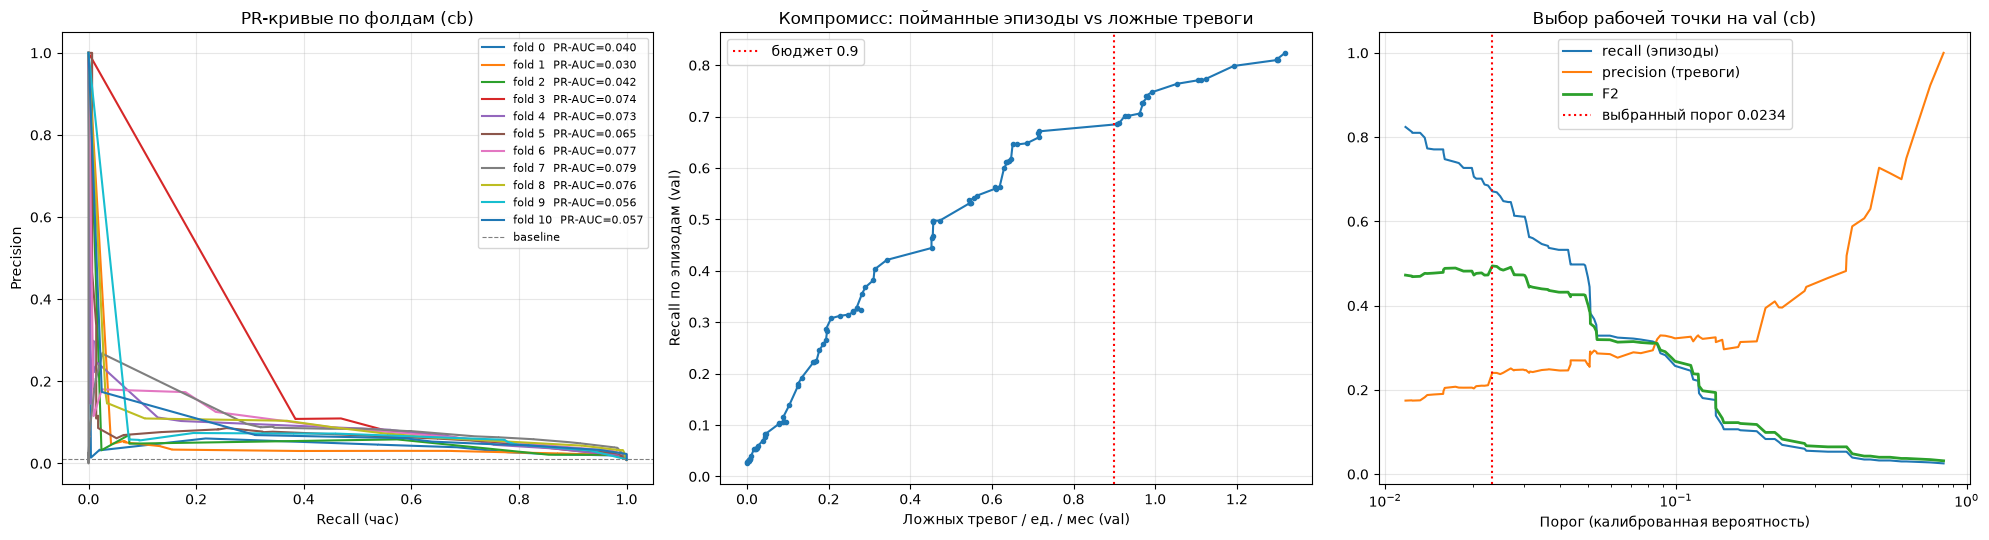

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

ax = axes[0]
for fold, g in oof_test.groupby('fold'):
    if g[TARGET].sum() == 0: continue
    p, r, _ = precision_recall_curve(g[TARGET], g[PCOL])
    ax.plot(r, p, label=f'fold {fold}  PR-AUC={average_precision_score(g[TARGET], g[PCOL]):.3f}')
ax.axhline(oof_test[TARGET].mean(), ls='--', c='grey', lw=0.8, label='baseline')
ax.set_xlabel('Recall (час)'); ax.set_ylabel('Precision')
ax.set_title(f'PR-кривые по фолдам ({MAIN_MODEL})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(thr_curve['fa'], thr_curve['recall_ep'], marker='.')
ax.axvline(FA_BUDGET, ls=':', c='red', label=f'бюджет {FA_BUDGET}')
ax.set_xlabel('Ложных тревог / ед. / мес (val)'); ax.set_ylabel('Recall по эпизодам (val)')
ax.set_title('Компромисс: пойманные эпизоды vs ложные тревоги')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(thr_curve['thr'], thr_curve['recall_ep'], label='recall (эпизоды)')
ax.plot(thr_curve['thr'], thr_curve['precision'], label='precision (тревоги)')
ax.plot(thr_curve['thr'], thr_curve['fbeta'], label=f'F{F_BETA:g}', lw=2)
ax.axvline(THR, ls=':', c='red', label=f'выбранный порог {THR:.4f}')
ax.set_xscale('log'); ax.set_xlabel('Порог (калиброванная вероятность)')
ax.set_title(f'Выбор рабочей точки на val ({MAIN_MODEL})')
ax.legend(); ax.grid(alpha=0.3)

fig.tight_layout()


### 7.4 Анализ важности признаков

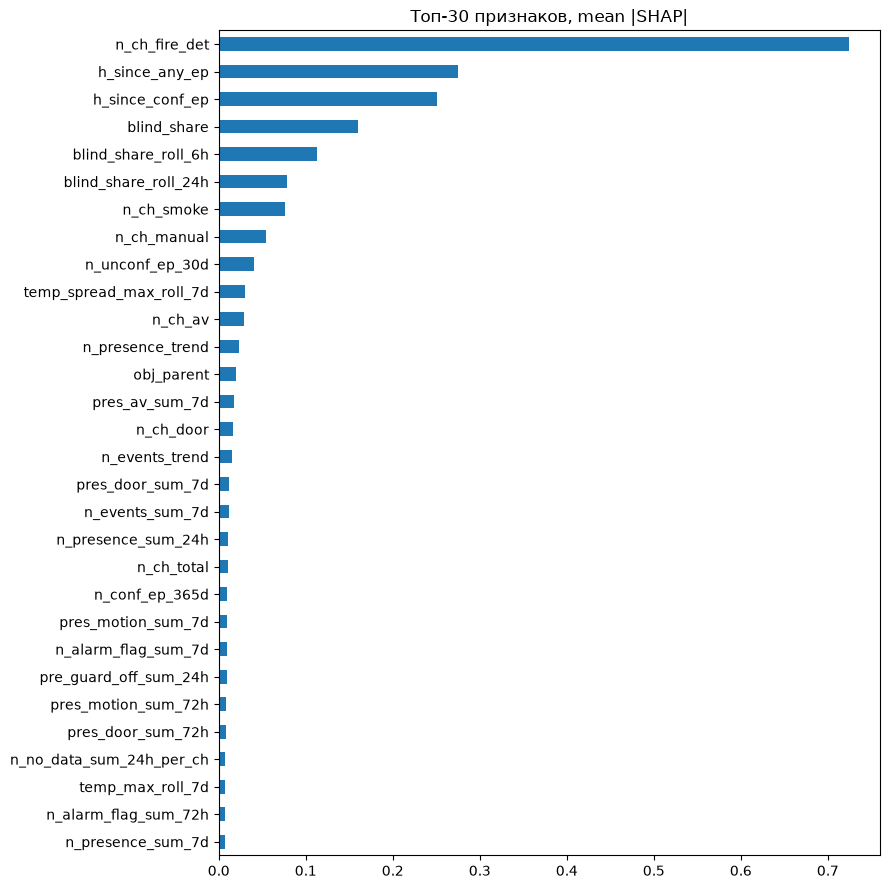

In [30]:
models_last, _ = fold_models[-1]
te_last = lab[lab['час'].between(FOLDS[-1]['test_start'], FOLDS[-1]['test_end'], inclusive='left')]
sample = te_last.sample(min(len(te_last), 50_000), random_state=SEED)
contrib = models_last['lgb'].predict(sample[FEATURES], pred_contrib=True,
                                     num_iteration=models_last['lgb'].best_iteration)
shap_imp = (pd.DataFrame(np.abs(contrib[:, :-1]), columns=FEATURES).mean()
              .sort_values(ascending=False).rename('mean_|SHAP|'))
shap_imp.to_csv(OUT_FOLDER / 'feature_importance_shap.csv')

fig, ax = plt.subplots(figsize=(9, 9))
shap_imp.head(30)[::-1].plot.barh(ax=ax); ax.set_title('Топ-30 признаков, mean |SHAP|'); plt.tight_layout(); plt.show()

## 8. Финальная модель и артефакты для сервиса

Финальная модель обучается на всех размеченных данных, кроме последних `VAL_DAYS` дней: они (после эмбарго) используются для early stopping и калибровки. Сохраняются модель, калибратор, порог, список признаков и конфигурация.

In [31]:
t_end = lab['час'].max()
val_start = t_end - pd.Timedelta(days=VAL_DAYS)
tr = lab[lab['час'] < val_start - EMBARGO]
va = lab[lab['час'] >= val_start]
final_models = fit_fold(tr, va, TARGET)
pv = raw_predict(final_models, va)
final_calib = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1).fit(pv[MAIN_MODEL], va[TARGET])

joblib.dump({'models': final_models, 'calibrator': final_calib, 'main_model': MAIN_MODEL,
             'features': FEATURES, 'baseline_features': BASELINE_FEATURES, 'threshold': THR},
            OUT_FOLDER / 'fire_risk_model_v2.joblib')
config = dict(MAIN_H=MAIN_H, HORIZONS=HORIZONS,
              EP_GAP_h=EP_GAP.total_seconds() / 3600, EP_CONFIRM_WINDOW_min=EP_CONFIRM_WINDOW.total_seconds() / 60,
              COOLDOWN_h=COOLDOWN.total_seconds() / 3600, FA_BUDGET=FA_BUDGET, THRESHOLD=THR,
              MAIN_MODEL=MAIN_MODEL, THR_OBJECTIVE=THR_OBJECTIVE, F_BETA=F_BETA,
              N_FEATURES=len(FEATURES), N_BASELINE_FEATURES=len(BASELINE_FEATURES),
              TEMP_FAULT_CODES=sorted(TEMP_FAULT_CODES), GAS_ALARM=GAS_ALARM, GAS_IMPLAUSIBLE=GAS_IMPLAUSIBLE,
              trained_until=str(t_end), n_confirmed_episodes=int(len(ep_conf)))
(OUT_FOLDER / 'config.json').write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8')
hour_metrics.to_csv(OUT_FOLDER / 'metrics_hourly.csv', index=False)
ep_metrics.to_csv(OUT_FOLDER / 'metrics_episodes.csv', index=False)
print('Сохранено в', OUT_FOLDER.resolve())
for p in sorted(OUT_FOLDER.iterdir()): print('  ', p.name)

Сохранено в C:\Users\a.rodin\1. PROJECTS_FOLDER\LST2026\artifacts_fire_v2
   config.json
   feature_importance_shap.csv
   fire_risk_model_v2 (more precision).joblib
   fire_risk_model_v2.joblib
   metrics_episodes.csv
   metrics_hourly.csv


## 9. Использование в сервисе (тестовый пример)
Для онлайн-прогноза новые события проходят шаги `process_journal` → сетка → признаки, затем:

In [32]:
art = joblib.load(OUT_FOLDER / 'fire_risk_model_v2.joblib')

def predict_risk(rows: pd.DataFrame) -> pd.DataFrame:
    # rows — строки сетки с рассчитанными признаками (последний час по каждой единице)
    p_raw = raw_predict(art['models'], rows)[art['main_model']]
    p = art['calibrator'].predict(p_raw)
    return rows[['unit', 't_pred']].assign(risk=p, alert=p >= art['threshold'])

latest = agg.sort_values('час').groupby('unit').tail(1)
display(predict_risk(latest).sort_values('risk', ascending=False).head(10))

,unit,t_pred,risk,alert
210293,99,2024-12-31 17:00:00,0.064103,True
3072321,5583,2024-12-25 18:00:00,0.064103,True
578052,3356,2025-01-01 00:00:00,0.057122,True
3268513,5677,2024-12-27 18:00:00,0.028333,True
2683593,5339,2024-12-31 16:00:00,0.028333,True
1629116,4648,2024-12-29 13:00:00,0.028333,True
52596,20,2024-12-31 22:00:00,0.020631,False
2886565,5567,2024-12-26 11:00:00,0.020631,False
2829229,5539,2024-12-03 11:00:00,0.008436,False
2799137,5537,2024-12-03 11:00:00,0.008436,False


## 10. РЕЗУЛЬТАТ

**Выводы при precision и recall равноценны**

При использовании F_BETA = 1.0:

 - Основная модель: cb
 - Порог 0.0271
 - Recall 0.6458 (65%)
 - Precision 0.2509 (25%)

**Выводы при акценте на precision**

При использовании F_BETA = 0.5:

 - Основная модель: cb
 - Порог 0.0885
 - Recall 0.2870 (29%)
 - Precision 0.3293 (33%)

**Выводы при акценте на recall**

При использовании F_BETA = 2.0:

 - Основная модель: cb 
 - Порог 0.0885
 - Recall 0.6713 (67%)
 - Precision 0.2404 (24%)

Две рабочие точки показывают следующее:

 - Первая точка (Recall 65%, Precision 25%). Ловим 2/3 пожаров, но 3 из 4 тревог — ложные.
 - Вторая точка (Recall 29%, Precision 33%). Ловим лишь 29% пожаров, 1 из 3 тревог — реальный.
 - Повышение порога 0.0271 → 0.0885 работает как ожидается:
   - Recall (65% → 29%) — пропускаем больше пожаров
   - Precision (25% → 33%) — меньше ложных срабатываний

**Как улучшить:**

Уже учтены дополнительные данные, которые смогут повысить качество предсказаний.

 - HOT_WORKS_FILE = DATA_FOLDER / 'арм_контроль_горячие_работы.csv' (Формат: [ид_объект], [начало], [окончание], [тип_работ])

 - WEATHER_FILE = DATA_FOLDER / 'погода_часовая.csv' (Формат: [дата и время], [температура], [влажность])

 - INCIDENTS_FILE = DATA_FOLDER / 'реестр_пожарных_инцидентов.csv' (Формат: [ид_объект], [datetime])


## 11. Тестовый раздел. Для написания программы

In [33]:
FEATURES

['n_events',
 'n_alarm_flag',
 'n_gas',
 'n_no_data',
 'n_presence',
 'n_risk',
 'pre_guard_off',
 'pre_ibp_battery',
 'pre_phase_fault',
 'pre_phase_off',
 'pre_pump_flood',
 'pre_pump_off',
 'pre_smoke_broken',
 'pre_smoke_off',
 'pre_uir_lever',
 'pres_av',
 'pres_door',
 'pres_guard',
 'pres_hatch',
 'pres_motion',
 'pres_uir',
 'risk_av',
 'risk_door',
 'risk_fan',
 'risk_flood',
 'risk_gas',
 'risk_glass',
 'risk_guard',
 'risk_hatch',
 'risk_heat',
 'risk_ibp',
 'risk_manual',
 'risk_power',
 'risk_pump',
 'risk_smoke',
 'risk_temp',
 'risk_uir',
 'uniq_ch_no_data',
 'uniq_ch_risk',
 'gas_max',
 'temp_max',
 'temp_min',
 'temp_dev_max',
 'temp_slope_max',
 'temp_spread_max',
 'n_temp_dev5',
 'n_blind_fd',
 'n_ch_av',
 'n_ch_door',
 'n_ch_fan',
 'n_ch_flood',
 'n_ch_gas',
 'n_ch_glass',
 'n_ch_guard',
 'n_ch_hatch',
 'n_ch_hatch9',
 'n_ch_heat',
 'n_ch_ibp',
 'n_ch_manual',
 'n_ch_motion',
 'n_ch_power',
 'n_ch_pump',
 'n_ch_smoke',
 'n_ch_switch',
 'n_ch_temp',
 'n_ch_uir',
 'n_

In [34]:
BASELINE_FEATURES

['n_risk_sum_24h',
 'risk_smoke_sum_7d',
 'blind_share',
 'temp_dev_max_roll_24h',
 'temp_slope_max_roll_6h',
 'temp_max_roll_24h',
 'n_presence_sum_24h',
 'pres_door_sum_24h',
 'pre_guard_off_sum_24h',
 'risk_power_sum_24h',
 'n_gas_sum_24h',
 'h_since_conf_ep',
 'n_unconf_ep_30d',
 'n_conf_ep_365d']